In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, LSTM, Bidirectional, Dropout
from tensorflow.keras.layers import Attention, GlobalAveragePooling1D
from tensorflow.keras.callbacks import EarlyStopping

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("CSE_CIC_IDS2018_6Class_10K.csv")

print(df.shape)
df.head()

(50415, 81)


,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,...,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,attack_class
0,53,17,23/02/2018 10:44:05,239,1,1,46,62.0,46,46,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,benign,Benign
1,53,17,23/02/2018 11:50:07,2196902,2,2,71,115.0,36,35,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,benign,Benign
2,53,17,14/02/2018 10:13:31,1179,1,1,42,96.0,42,42,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,benign,Benign
3,445,6,15/02/2018 01:31:54,1330440,6,5,455,338.0,140,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,benign,Benign
4,53,17,23/02/2018 01:57:45,332,1,1,39,55.0,39,39,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,benign,Benign


In [3]:
print(df['attack_class'].value_counts())

attack_class
Benign          10000
Botnet          10000
Brute Force     10000
DDoS            10000
Infiltration    10000
Web attacks       415
Name: count, dtype: int64


In [4]:
remove_cols = ['Timestamp','Flow ID','Src IP','Dst IP']

for col in remove_cols:
    if col in df.columns:
        df.drop(col, axis=1, inplace=True)

In [5]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)

df.dropna(inplace=True)

In [6]:
# Remove duplicate rows
df = df.drop_duplicates()

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (35168, 80)


In [7]:
import numpy as np

# Select only numeric columns
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    
    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)

    df[col] = df[col].clip(lower, upper)

print("Noise reduction completed")

Noise reduction completed


In [8]:
print(df['attack_class'].value_counts())

attack_class
Benign          9772
Infiltration    9679
DDoS            7123
Botnet          5610
Brute Force     2591
Web attacks      393
Name: count, dtype: int64


In [9]:
print("Dataset shape after noise removal:", df.shape)

Dataset shape after noise removal: (35168, 80)


In [10]:
le = LabelEncoder()

df['attack_class'] = le.fit_transform(df['attack_class'])

In [11]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['attack_class'] = le.fit_transform(df['attack_class'])

print("Classes:", le.classes_)

Classes: [0 1 2 3 4 5]


In [12]:
X = df.drop('attack_class', axis=1)

y = df['attack_class']

print("Feature shape:", X.shape)
print("Label shape:", y.shape)

Feature shape: (35168, 79)
Label shape: (35168,)


In [13]:
# Remove non-numeric columns
non_numeric_cols = df.select_dtypes(exclude=['int64','float64']).columns

print("Removing non-numeric columns:", non_numeric_cols)

df = df.drop(columns=non_numeric_cols)

Removing non-numeric columns: Index(['Label'], dtype='object')


In [14]:
# Keep label column separately
y = df['attack_class']

# Keep only numeric features
X = df.select_dtypes(include=['int64','float64'])

print("Feature columns:", X.shape)

Feature columns: (35168, 79)


In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [16]:
from sklearn.feature_selection import VarianceThreshold

var_selector = VarianceThreshold(threshold=0.01)

X_var = var_selector.fit_transform(X_scaled)

print("Shape after variance filtering:", X_var.shape)

Shape after variance filtering: (35168, 68)


In [17]:
import numpy as np

# Replace infinity with NaN
X_var = np.where(np.isinf(X_var), np.nan, X_var)

# Replace NaN with column mean
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="mean")

X_var = imputer.fit_transform(X_var)

print("NaN handling completed")

NaN handling completed


In [18]:
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k=40)

X_selected = selector.fit_transform(X_var, y)

print("Shape after feature selection:", X_selected.shape)

Shape after feature selection: (35168, 40)


In [19]:
print("Total NaN values:", np.isnan(X_selected).sum())

Total NaN values: 0


In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_selected,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [21]:
X_train = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))

X_test = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))

In [22]:
import numpy as np
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.layers import Attention, GlobalAveragePooling1D
from tensorflow.keras.optimizers import Adam

input_layer = Input(shape=(1, X_train.shape[2]))

# Reduced LSTM units
bilstm = Bidirectional(
    LSTM(64, return_sequences=True)
)(input_layer)

# Attention layer
attention = Attention()([bilstm, bilstm])

# Pooling
pool = GlobalAveragePooling1D()(attention)

# Smaller dense layer
dense = Dense(32, activation='relu')(pool)

# Balanced dropout
drop = Dropout(0.6)(dense)

# Output layer
output = Dense(len(np.unique(y)), activation='softmax')(drop)

model = Model(inputs=input_layer, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=0.00008),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 1, 40)]      0           []                               
                                                                                                  
 bidirectional (Bidirectional)  (None, 1, 128)       53760       ['input_1[0][0]']                
                                                                                                  
 attention (Attention)          (None, 1, 128)       0           ['bidirectional[0][0]',          
                                                                  'bidirectional[0][0]']          
                                                                                                  
 global_average_pooling1d (Glob  (None, 128)         0           ['attention[0][0]']          

In [23]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/20
308/308 [==============================] - 3s 4ms/step - loss: 1.5777 - accuracy: 0.4376 - val_loss: 1.3543 - val_accuracy: 0.7271
Epoch 2/20
308/308 [==============================] - 1s 2ms/step - loss: 1.2425 - accuracy: 0.6289 - val_loss: 0.9861 - val_accuracy: 0.8643
Epoch 3/20
308/308 [==============================] - 1s 2ms/step - loss: 0.9629 - accuracy: 0.7306 - val_loss: 0.6667 - val_accuracy: 0.9175
Epoch 4/20
308/308 [==============================] - 1s 2ms/step - loss: 0.7212 - accuracy: 0.8050 - val_loss: 0.4155 - val_accuracy: 0.9352
Epoch 5/20
308/308 [==============================] - 1s 2ms/step - loss: 0.5485 - accuracy: 0.8554 - val_loss: 0.2801 - val_accuracy: 0.9618
Epoch 6/20
308/308 [==============================] - 1s 2ms/step - loss: 0.4445 - accuracy: 0.8828 - val_loss: 0.2028 - val_accuracy: 0.9653
Epoch 7/20
308/308 [==============================] - 1s 2ms/step - loss: 0.3766 - accuracy: 0.9010 - val_loss: 0.1547 - val_accuracy: 0.9679
Epoch 

In [24]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

y_pred = np.argmax(y_pred, axis=1)

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

print(classification_report(y_test, y_pred))

330/330 [==============================] - 1s 710us/step
Model Accuracy: 0.9890057814425173
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2932
           1       1.00      1.00      1.00      1683
           2       1.00      0.98      0.99       777
           3       0.99      0.99      0.99      2137
           4       0.97      1.00      0.98      2904
           5       1.00      0.37      0.54       118

    accuracy                           0.99     10551
   macro avg       0.99      0.89      0.92     10551
weighted avg       0.99      0.99      0.99     10551



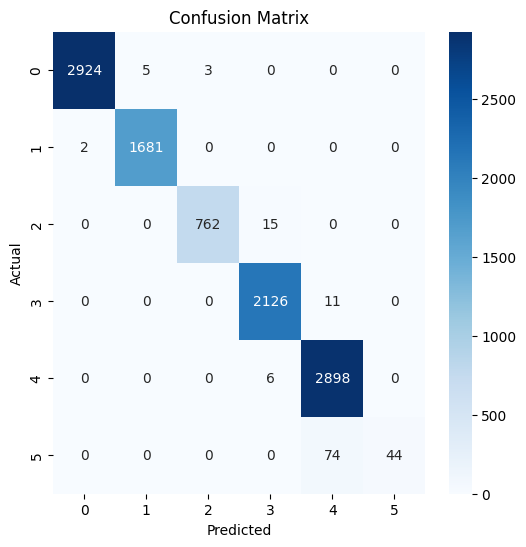

In [25]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [26]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.weight"] = "bold"
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.grid"] = False

In [27]:
class_names = le.classes_

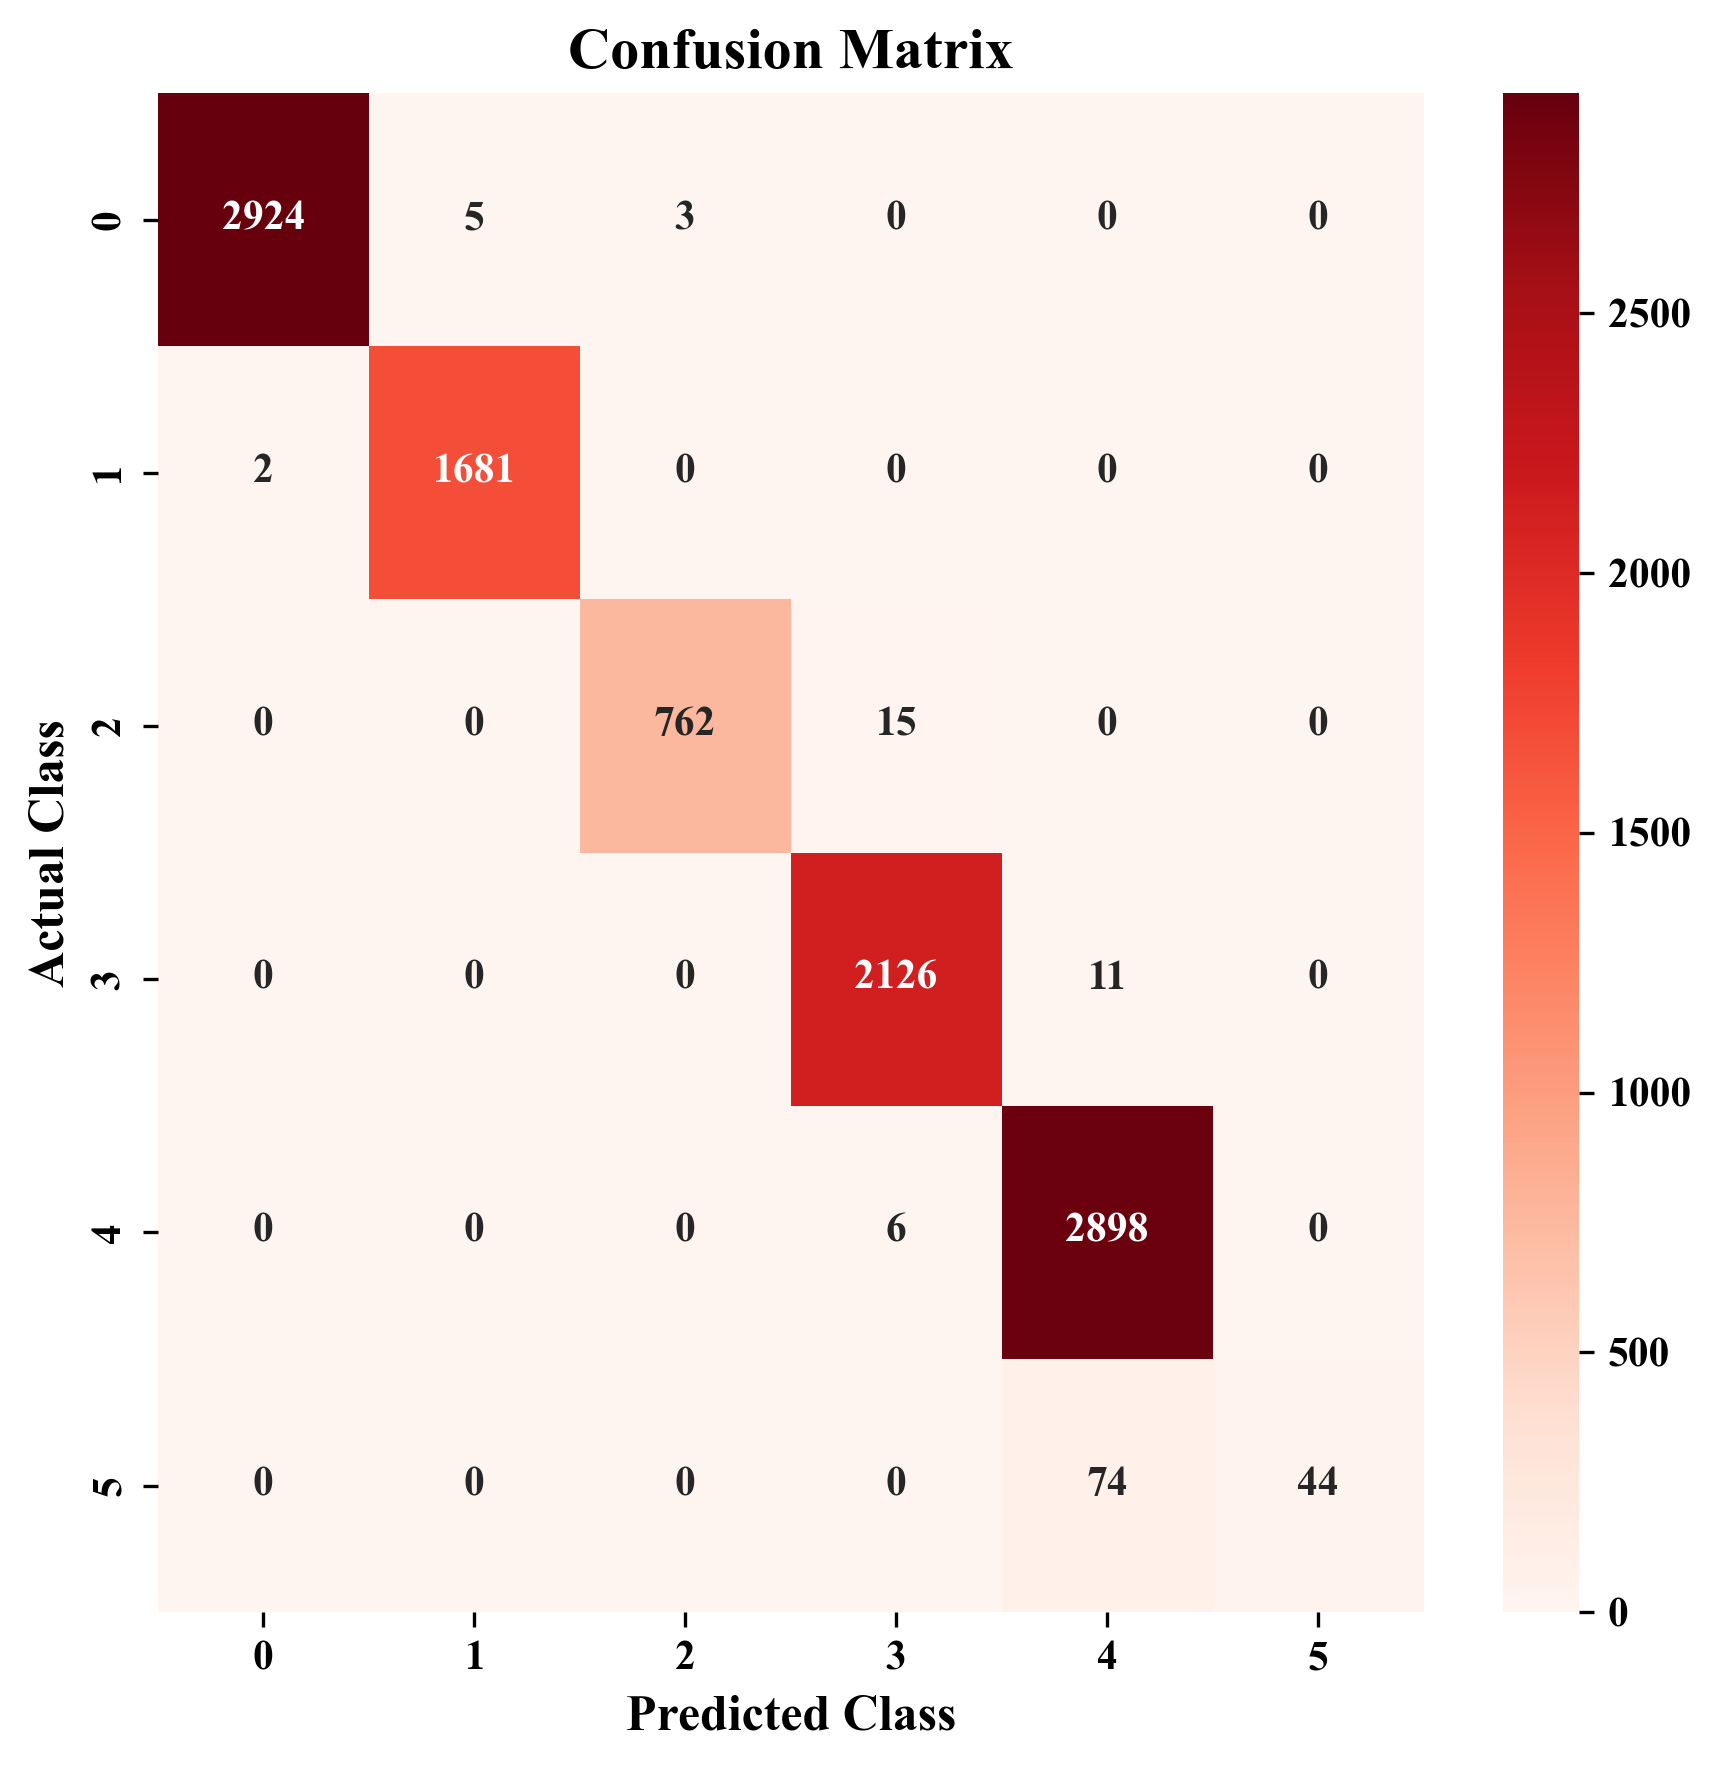

In [28]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,6), dpi=300)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Reds",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Class", fontsize=12, fontweight='bold')
plt.ylabel("Actual Class", fontsize=12, fontweight='bold')
plt.title("Confusion Matrix", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=300)
plt.show()

In [29]:
class_names = [
    "Benign",
    "Infiltration",
    "Botnet",
    "DDoS",
    "Brute Force",
    "Web attacks"
]

In [30]:
cm = confusion_matrix(y_test, y_pred)

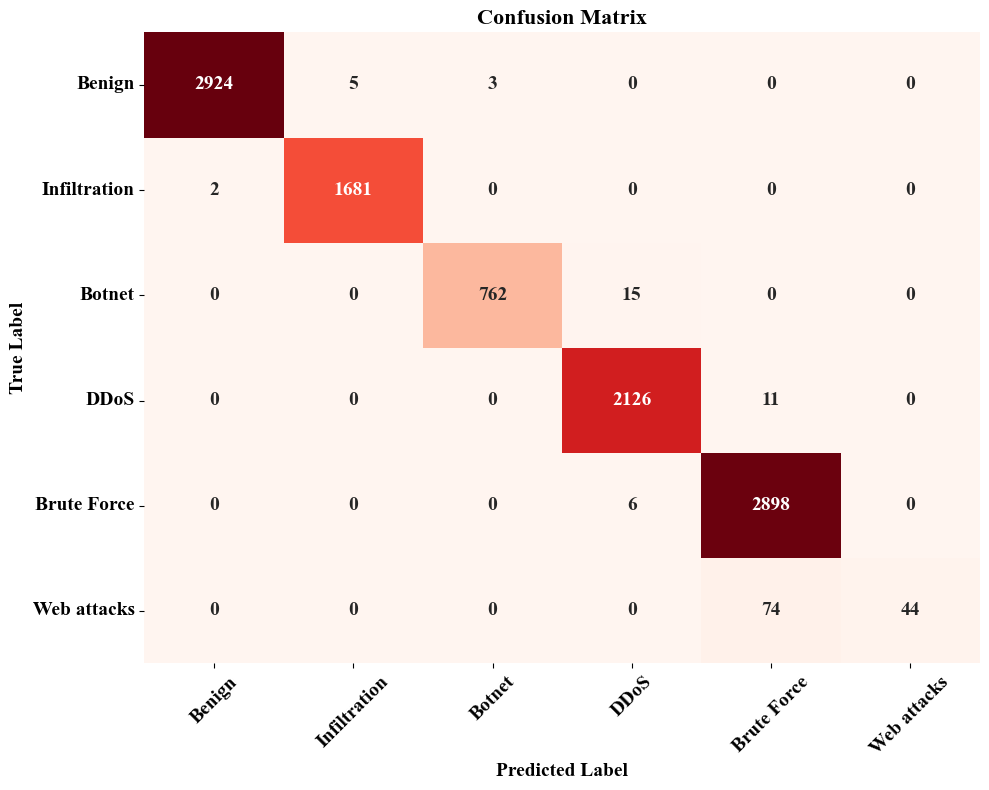

In [31]:
plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Reds',
    xticklabels=class_names,
    yticklabels=class_names,
    cbar=False,
    annot_kws={"size":14, "weight":"bold", "family":"Times New Roman"}
)

plt.xlabel(
    "Predicted Label",
    fontsize=14,
    fontweight='bold',
    fontname='Times New Roman'
)

plt.ylabel(
    "True Label",
    fontsize=14,
    fontweight='bold',
    fontname='Times New Roman'
)

plt.title(
    "Confusion Matrix",
    fontsize=16,
    fontweight='bold',
    fontname='Times New Roman'
)

plt.xticks(fontsize=14, fontweight='bold', fontname='Times New Roman', rotation=45)
plt.yticks(fontsize=14, fontweight='bold', fontname='Times New Roman', rotation=0)

plt.grid(False)

plt.tight_layout()

plt.savefig(
    "confusion_matrix.png",
    dpi=300,
    format="png"
)

plt.show()

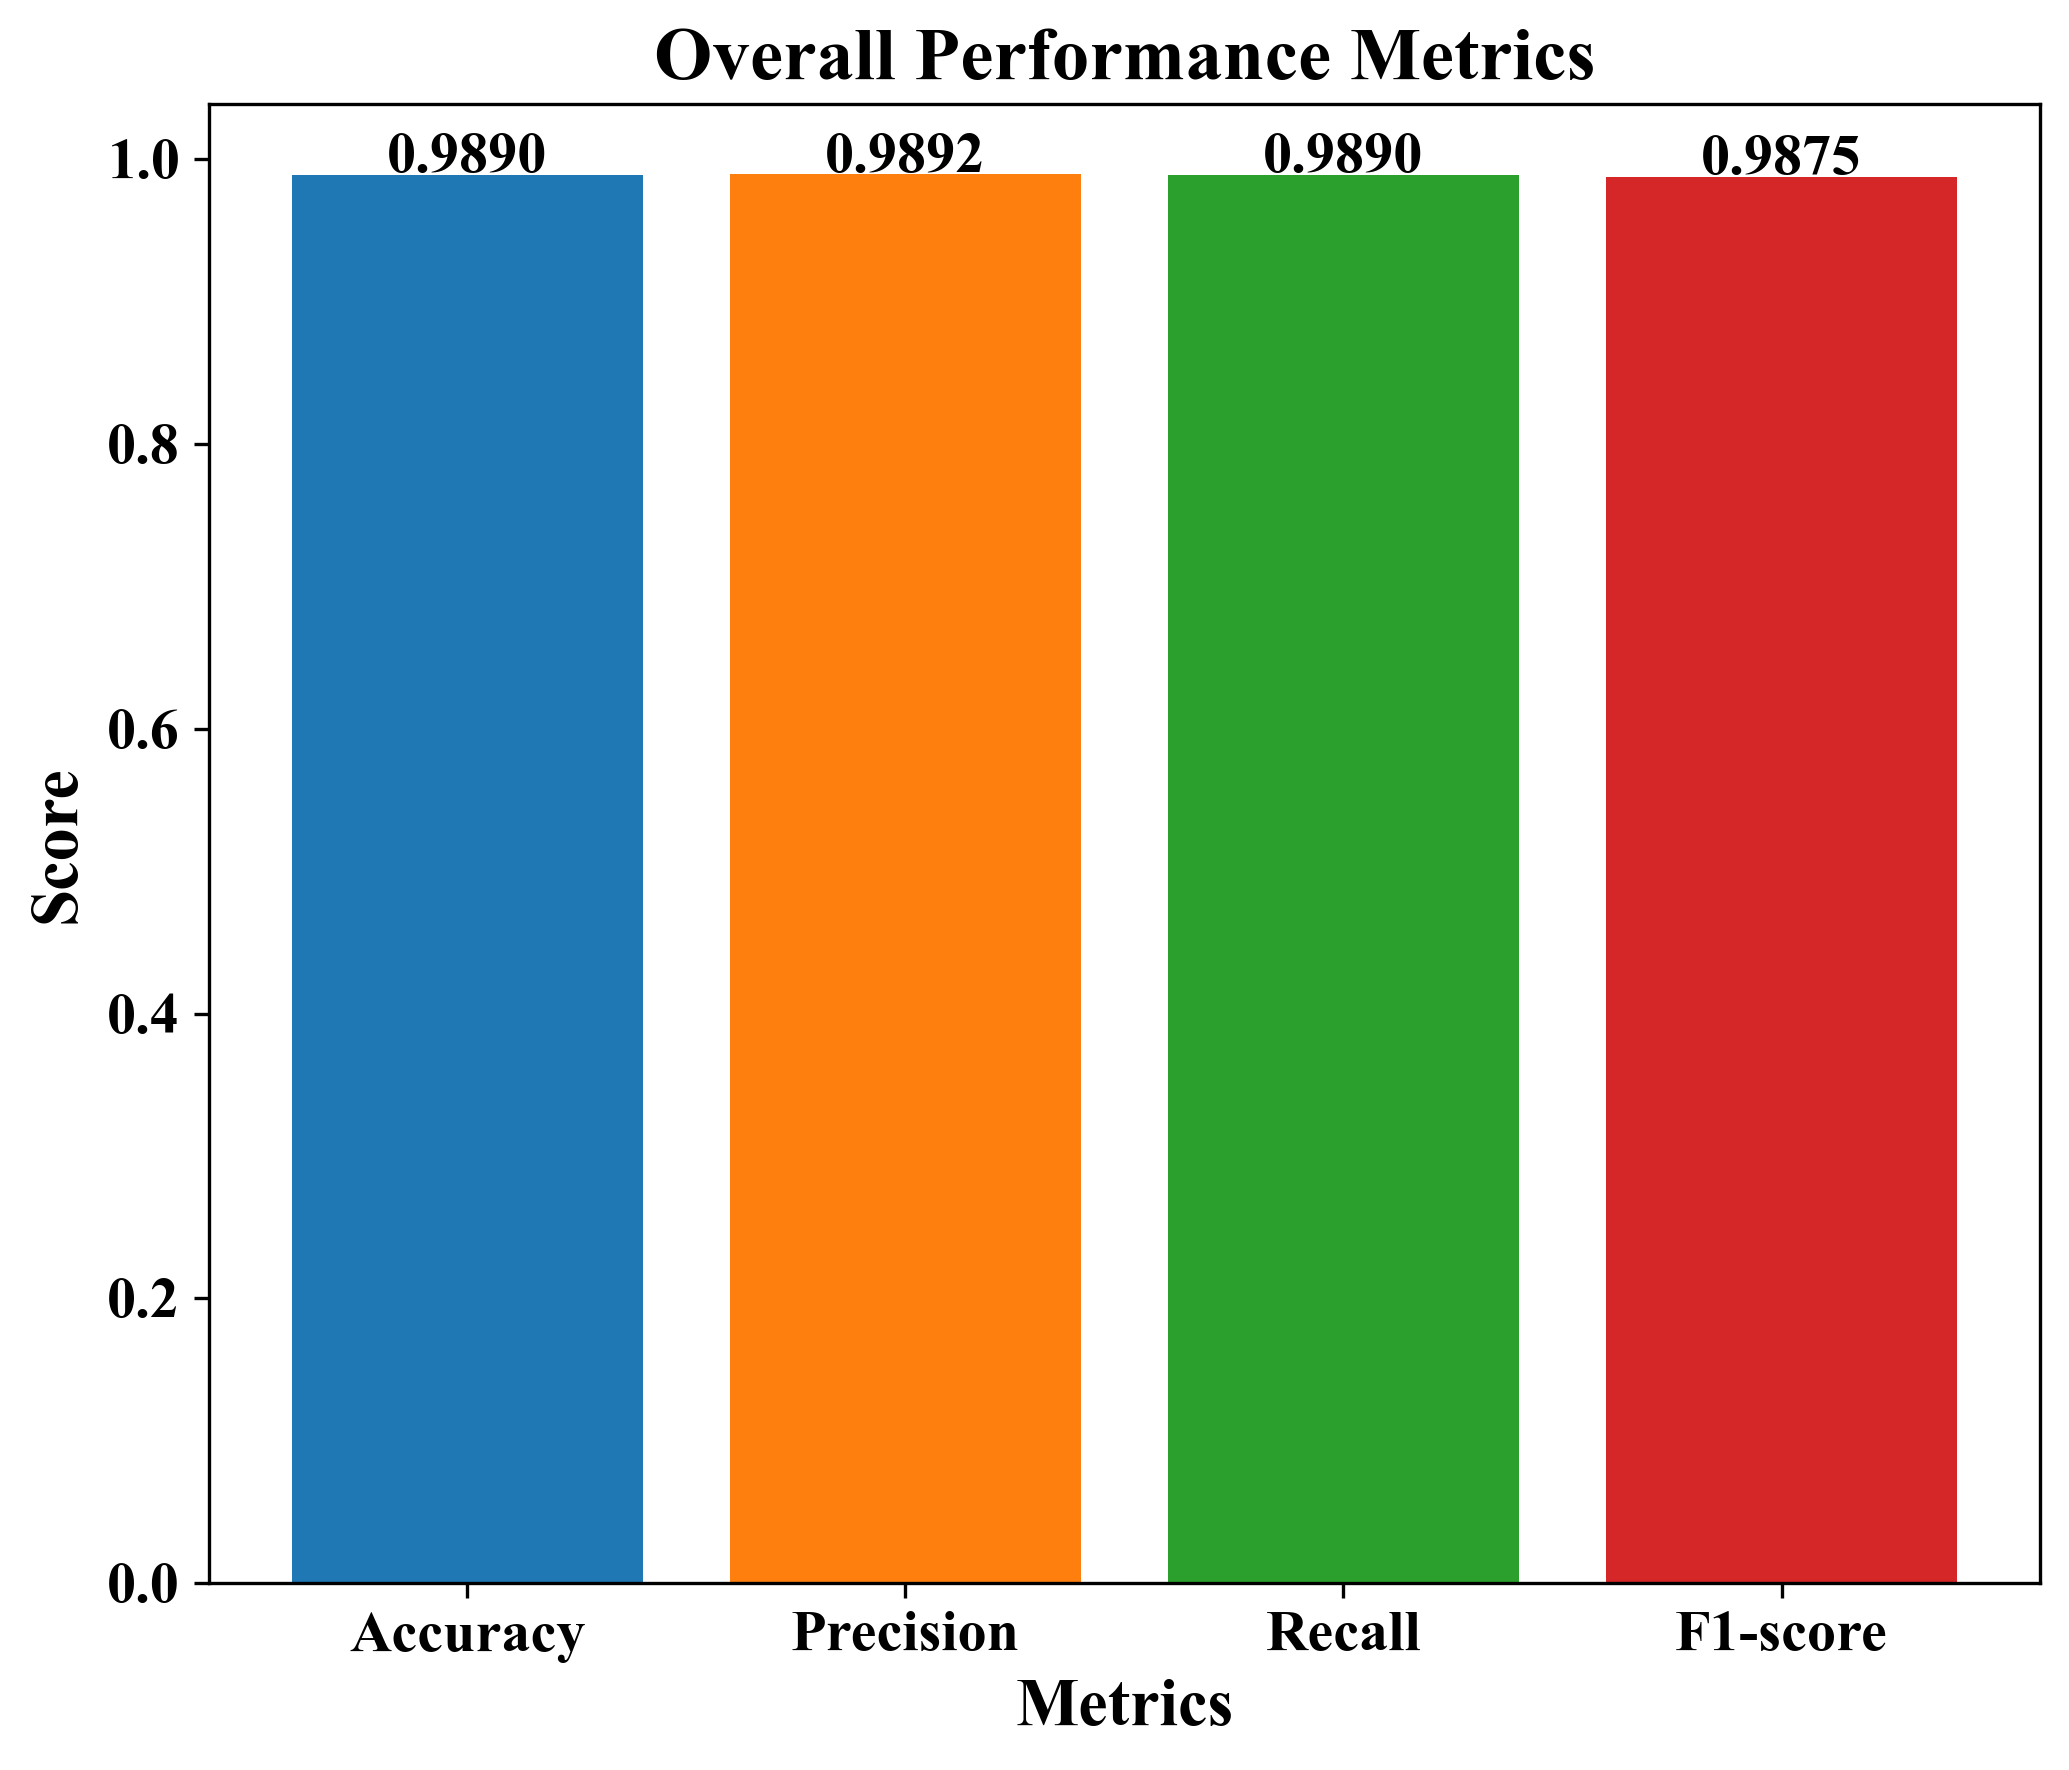

In [32]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import numpy as np

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

metrics = [accuracy, precision, recall, f1]
labels = ["Accuracy", "Precision", "Recall", "F1-score"]

# unique colors
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]

plt.figure(figsize=(7,6), dpi=300)

bars = plt.bar(labels, metrics, color=colors)

# Add bar values
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.002,
        f"{height:.4f}",
        ha='center',
        fontsize=14,
        fontweight='bold',
        fontname='Times New Roman'
    )

plt.ylabel("Score", fontsize=16, fontweight='bold', fontname='Times New Roman')
plt.xlabel("Metrics", fontsize=16, fontweight='bold', fontname='Times New Roman')
plt.title("Overall Performance Metrics", fontsize=18, fontweight='bold', fontname='Times New Roman')

plt.xticks(fontsize=14, fontweight='bold', fontname='Times New Roman')
plt.yticks(fontsize=14, fontweight='bold', fontname='Times New Roman')

plt.grid(False)

plt.tight_layout()
plt.savefig("overall_metrics.png", dpi=300, bbox_inches="tight")
plt.show()

<Figure size 3600x2400 with 0 Axes>

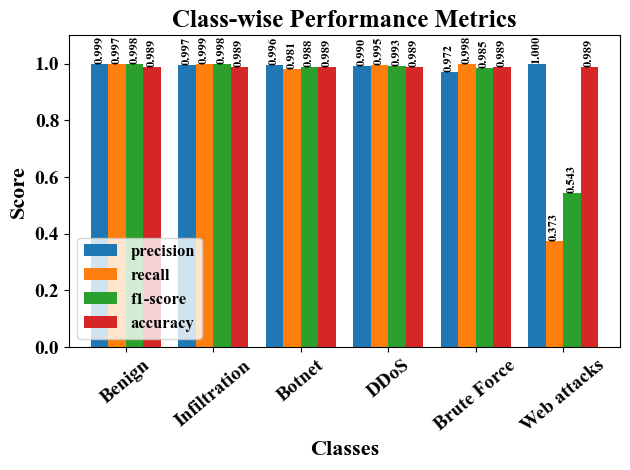

In [33]:
from sklearn.metrics import classification_report, accuracy_score
import pandas as pd
import matplotlib.pyplot as plt

# classification report
report = classification_report(y_test, y_pred, output_dict=True)

df_report = pd.DataFrame(report).transpose().iloc[:-3]

# manual class names
class_names = [
    "Benign",
    "Infiltration",
    "Botnet",
    "DDoS",
    "Brute Force",
    "Web attacks"
]

df_report.index = class_names

# overall accuracy
accuracy = accuracy_score(y_test, y_pred)

# add accuracy column
df_report['accuracy'] = accuracy

plt.figure(figsize=(12,8), dpi=300)

ax = df_report[['precision','recall','f1-score','accuracy']].plot(
    kind='bar',
    width=0.8
)

# add bar values
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        fontsize=9,
        rotation=90,
        fontweight='bold',
        fontname='Times New Roman'
    )

plt.xlabel(
    "Classes",
    fontsize=16,
    fontweight='bold',
    fontname='Times New Roman'
)

plt.ylabel(
    "Score",
    fontsize=16,
    fontweight='bold',
    fontname='Times New Roman'
)

plt.title(
    "Class-wise Performance Metrics",
    fontsize=18,
    fontweight='bold',
    fontname='Times New Roman'
)

plt.xticks(
    rotation=40,
    fontsize=14,
    fontweight='bold',
    fontname='Times New Roman'
)

plt.yticks(
    fontsize=14,
    fontweight='bold',
    fontname='Times New Roman'
)

plt.legend(
    prop={'family':'Times New Roman','weight':'bold','size':12}
)
plt.ylim(0, 1.1)
plt.grid(False)

plt.tight_layout()

plt.savefig(
    "classwise_metrics.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

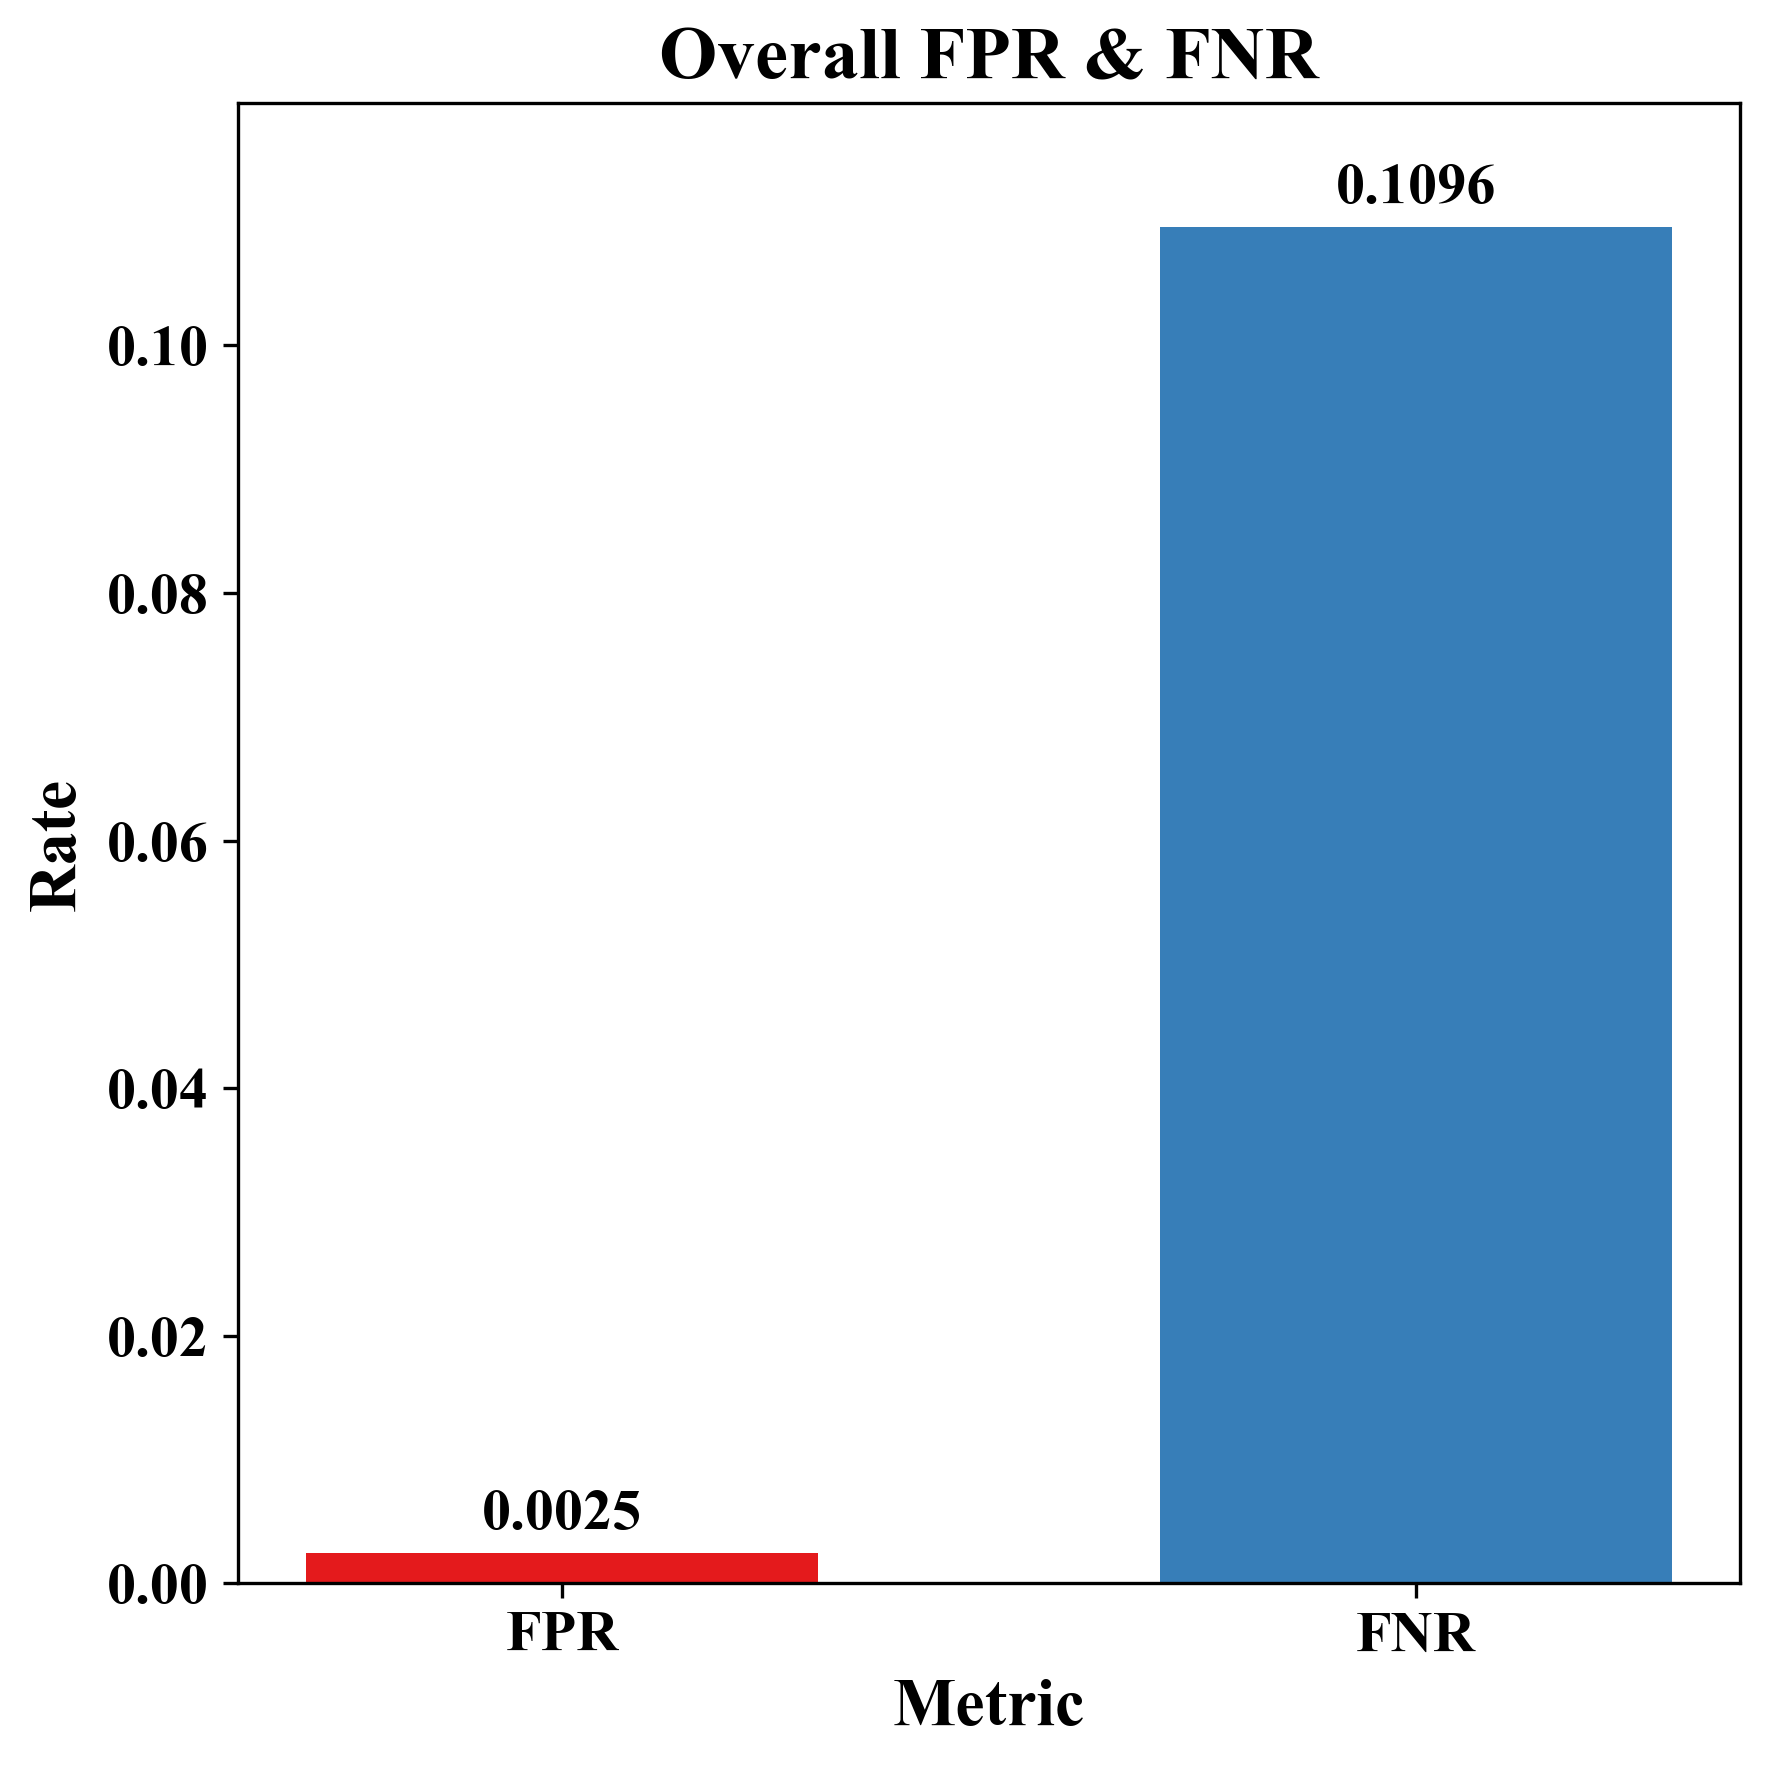

In [34]:
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

FP = cm.sum(axis=0) - np.diag(cm)
FN = cm.sum(axis=1) - np.diag(cm)
TP = np.diag(cm)
TN = cm.sum() - (FP + FN + TP)

FPR = FP / (FP + TN)
FNR = FN / (FN + TP)

overall_fpr = np.mean(FPR)
overall_fnr = np.mean(FNR)

values = [overall_fpr, overall_fnr]
labels = ["FPR", "FNR"]

# unique colors
colors = ["#e41a1c", "#377eb8"]

plt.figure(figsize=(6,6), dpi=300)

bars = plt.bar(labels, values, color=colors, width=0.6)

# add bar values
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.002,
        f"{height:.4f}",
        ha='center',
        fontsize=14,
        fontweight='bold',
        fontname='Times New Roman'
    )

plt.xlabel(
    "Metric",
    fontsize=16,
    fontweight='bold',
    fontname='Times New Roman'
)

plt.ylabel(
    "Rate",
    fontsize=16,
    fontweight='bold',
    fontname='Times New Roman'
)

plt.title(
    "Overall FPR & FNR",
    fontsize=18,
    fontweight='bold',
    fontname='Times New Roman'
)

plt.xticks(
    fontsize=14,
    fontweight='bold',
    fontname='Times New Roman'
)

plt.yticks(
    fontsize=14,
    fontweight='bold',
    fontname='Times New Roman'
)

plt.ylim(0, max(values) + 0.01)

plt.grid(False)

plt.tight_layout()

plt.savefig(
    "overall_fpr_fnr.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [35]:
y_pred_prob = model.predict(X_test)

330/330 [==============================] - 0s 767us/step


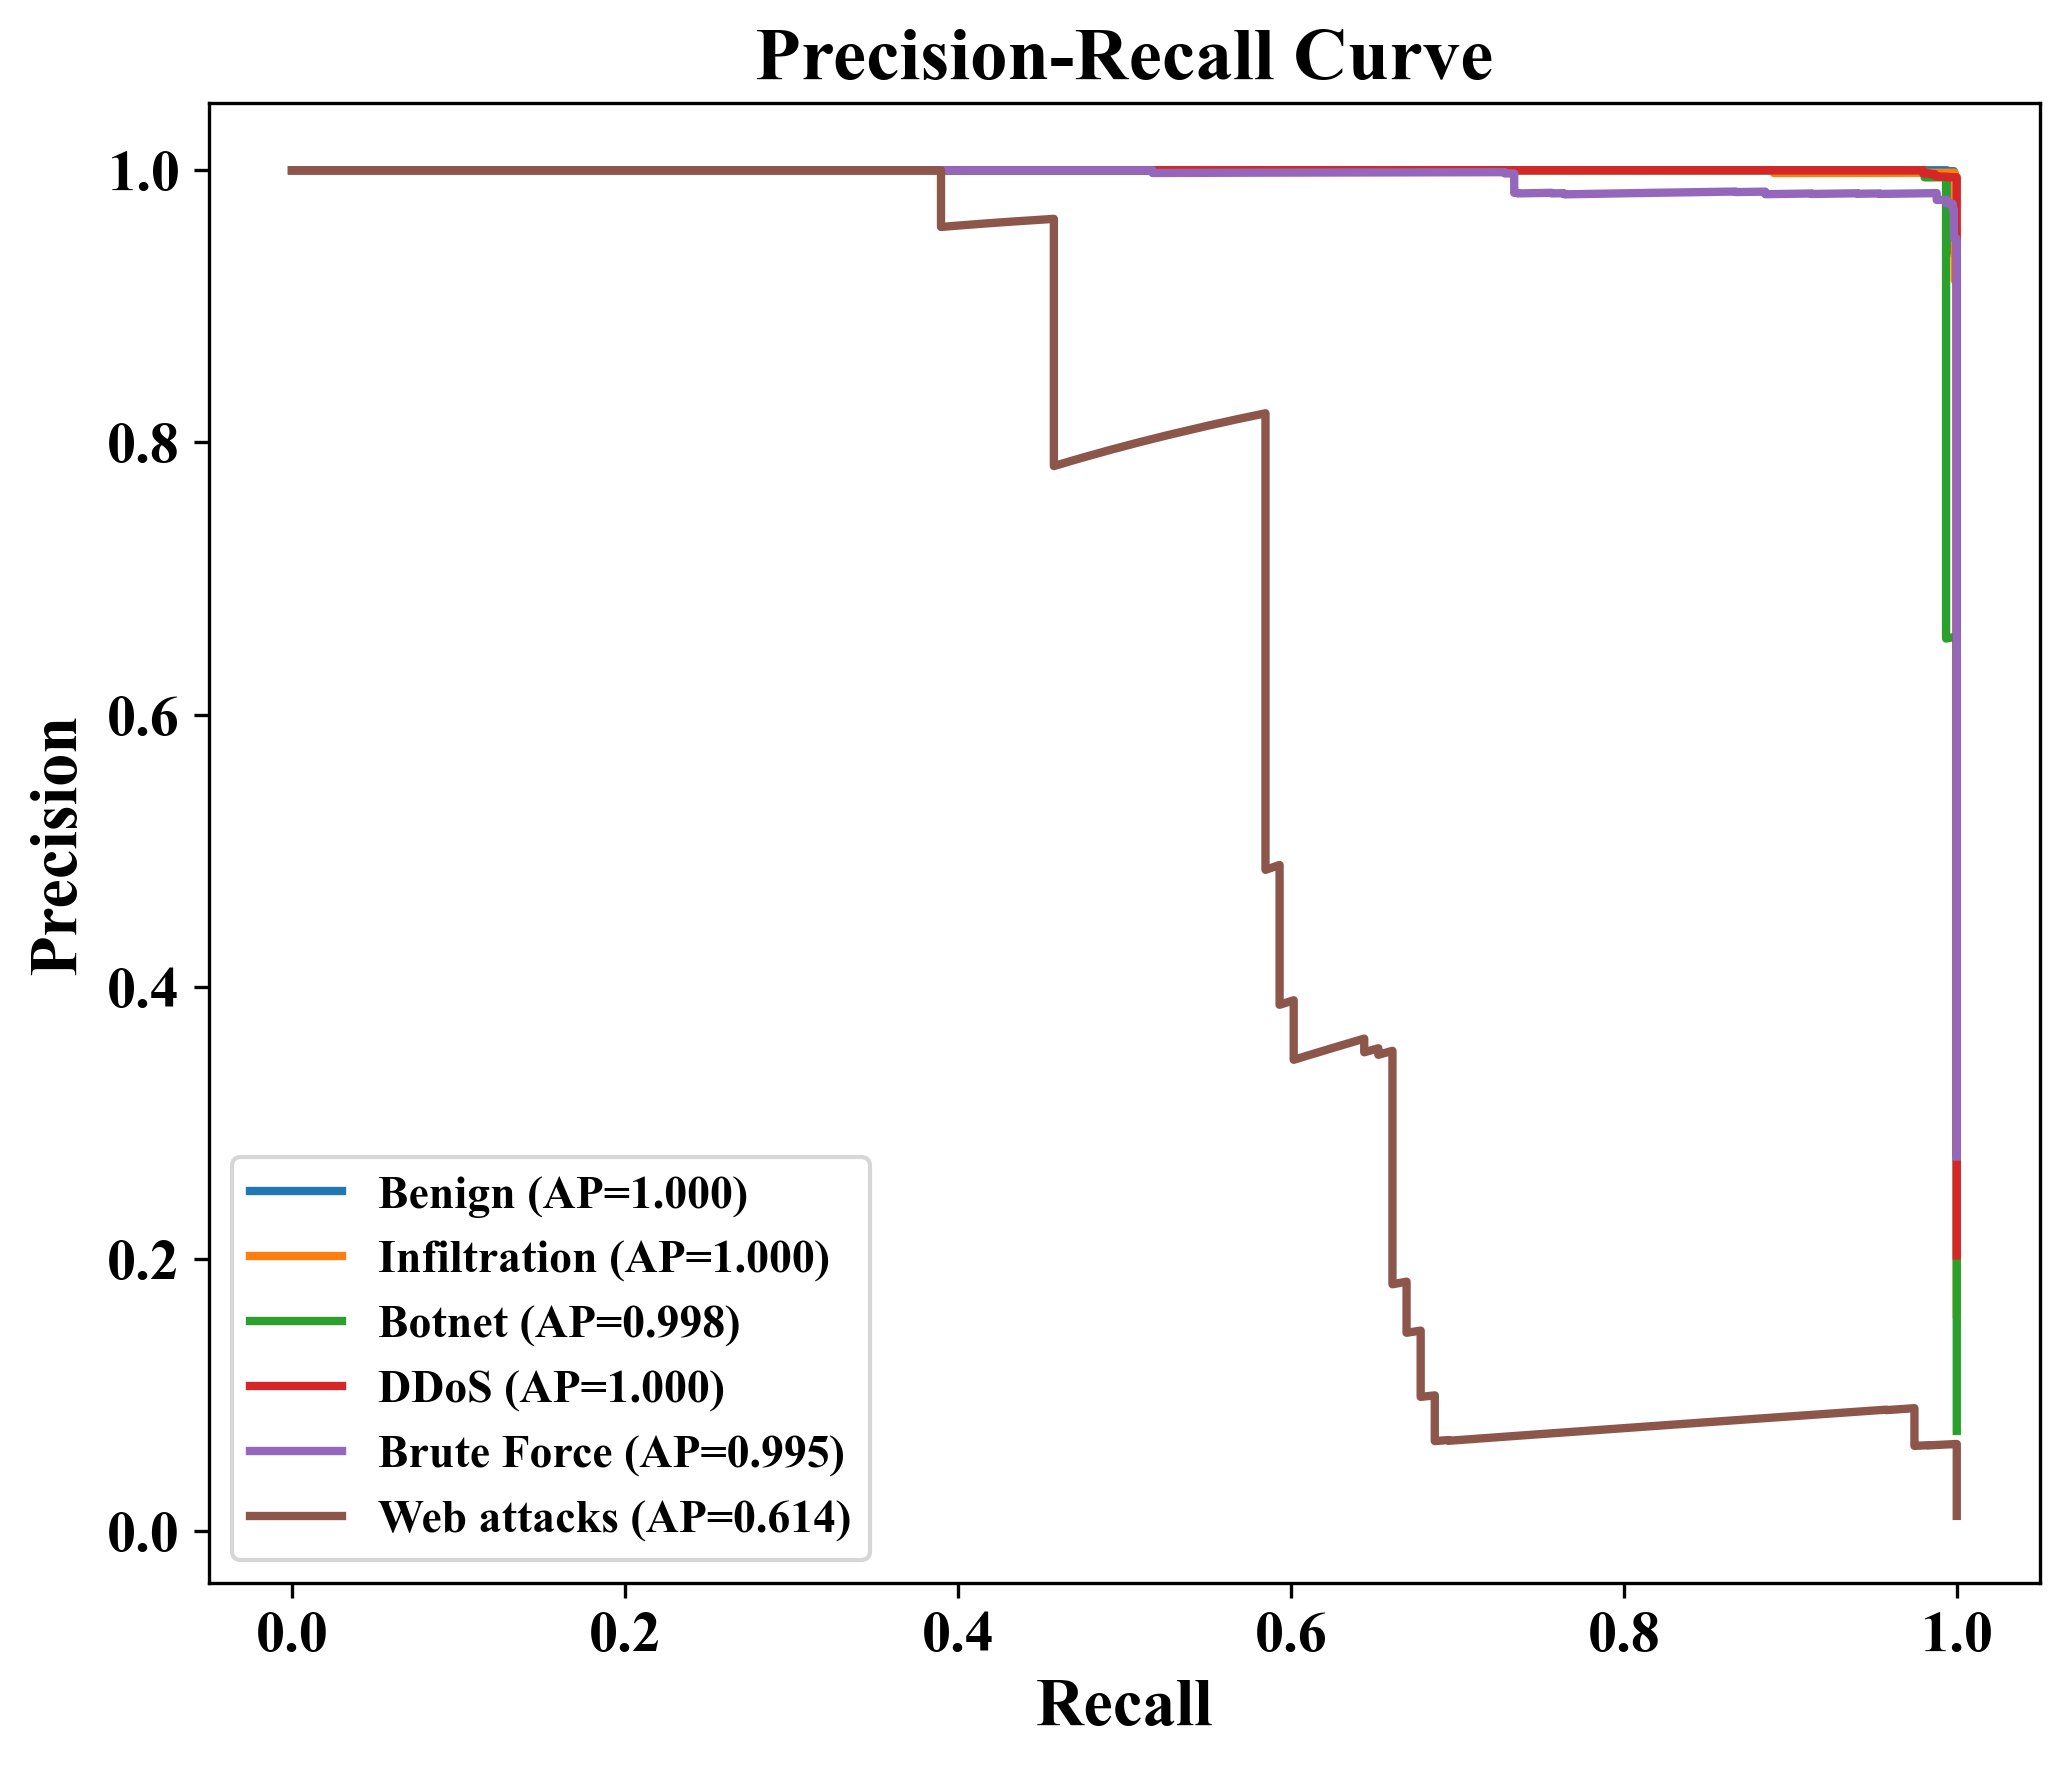

In [36]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

y_test_bin = label_binarize(y_test, classes=range(len(class_names)))

plt.figure(figsize=(7,6), dpi=300)

for i in range(len(class_names)):
    
    precision, recall, _ = precision_recall_curve(
        y_test_bin[:, i],
        y_pred_prob[:, i]
    )

    ap = average_precision_score(
        y_test_bin[:, i],
        y_pred_prob[:, i]
    )

    plt.plot(
        recall,
        precision,
        linewidth=2,
        label=f"{class_names[i]} (AP={ap:.3f})"
    )

plt.xlabel(
    "Recall",
    fontsize=16,
    fontweight='bold',
    fontname='Times New Roman'
)

plt.ylabel(
    "Precision",
    fontsize=16,
    fontweight='bold',
    fontname='Times New Roman'
)

plt.title(
    "Precision-Recall Curve",
    fontsize=18,
    fontweight='bold',
    fontname='Times New Roman'
)

plt.xticks(fontsize=14, fontweight='bold', fontname='Times New Roman')
plt.yticks(fontsize=14, fontweight='bold', fontname='Times New Roman')

plt.legend(
    prop={'family':'Times New Roman','weight':'bold','size':11}
)

plt.grid(False)

plt.tight_layout()

plt.savefig(
    "precision_recall_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

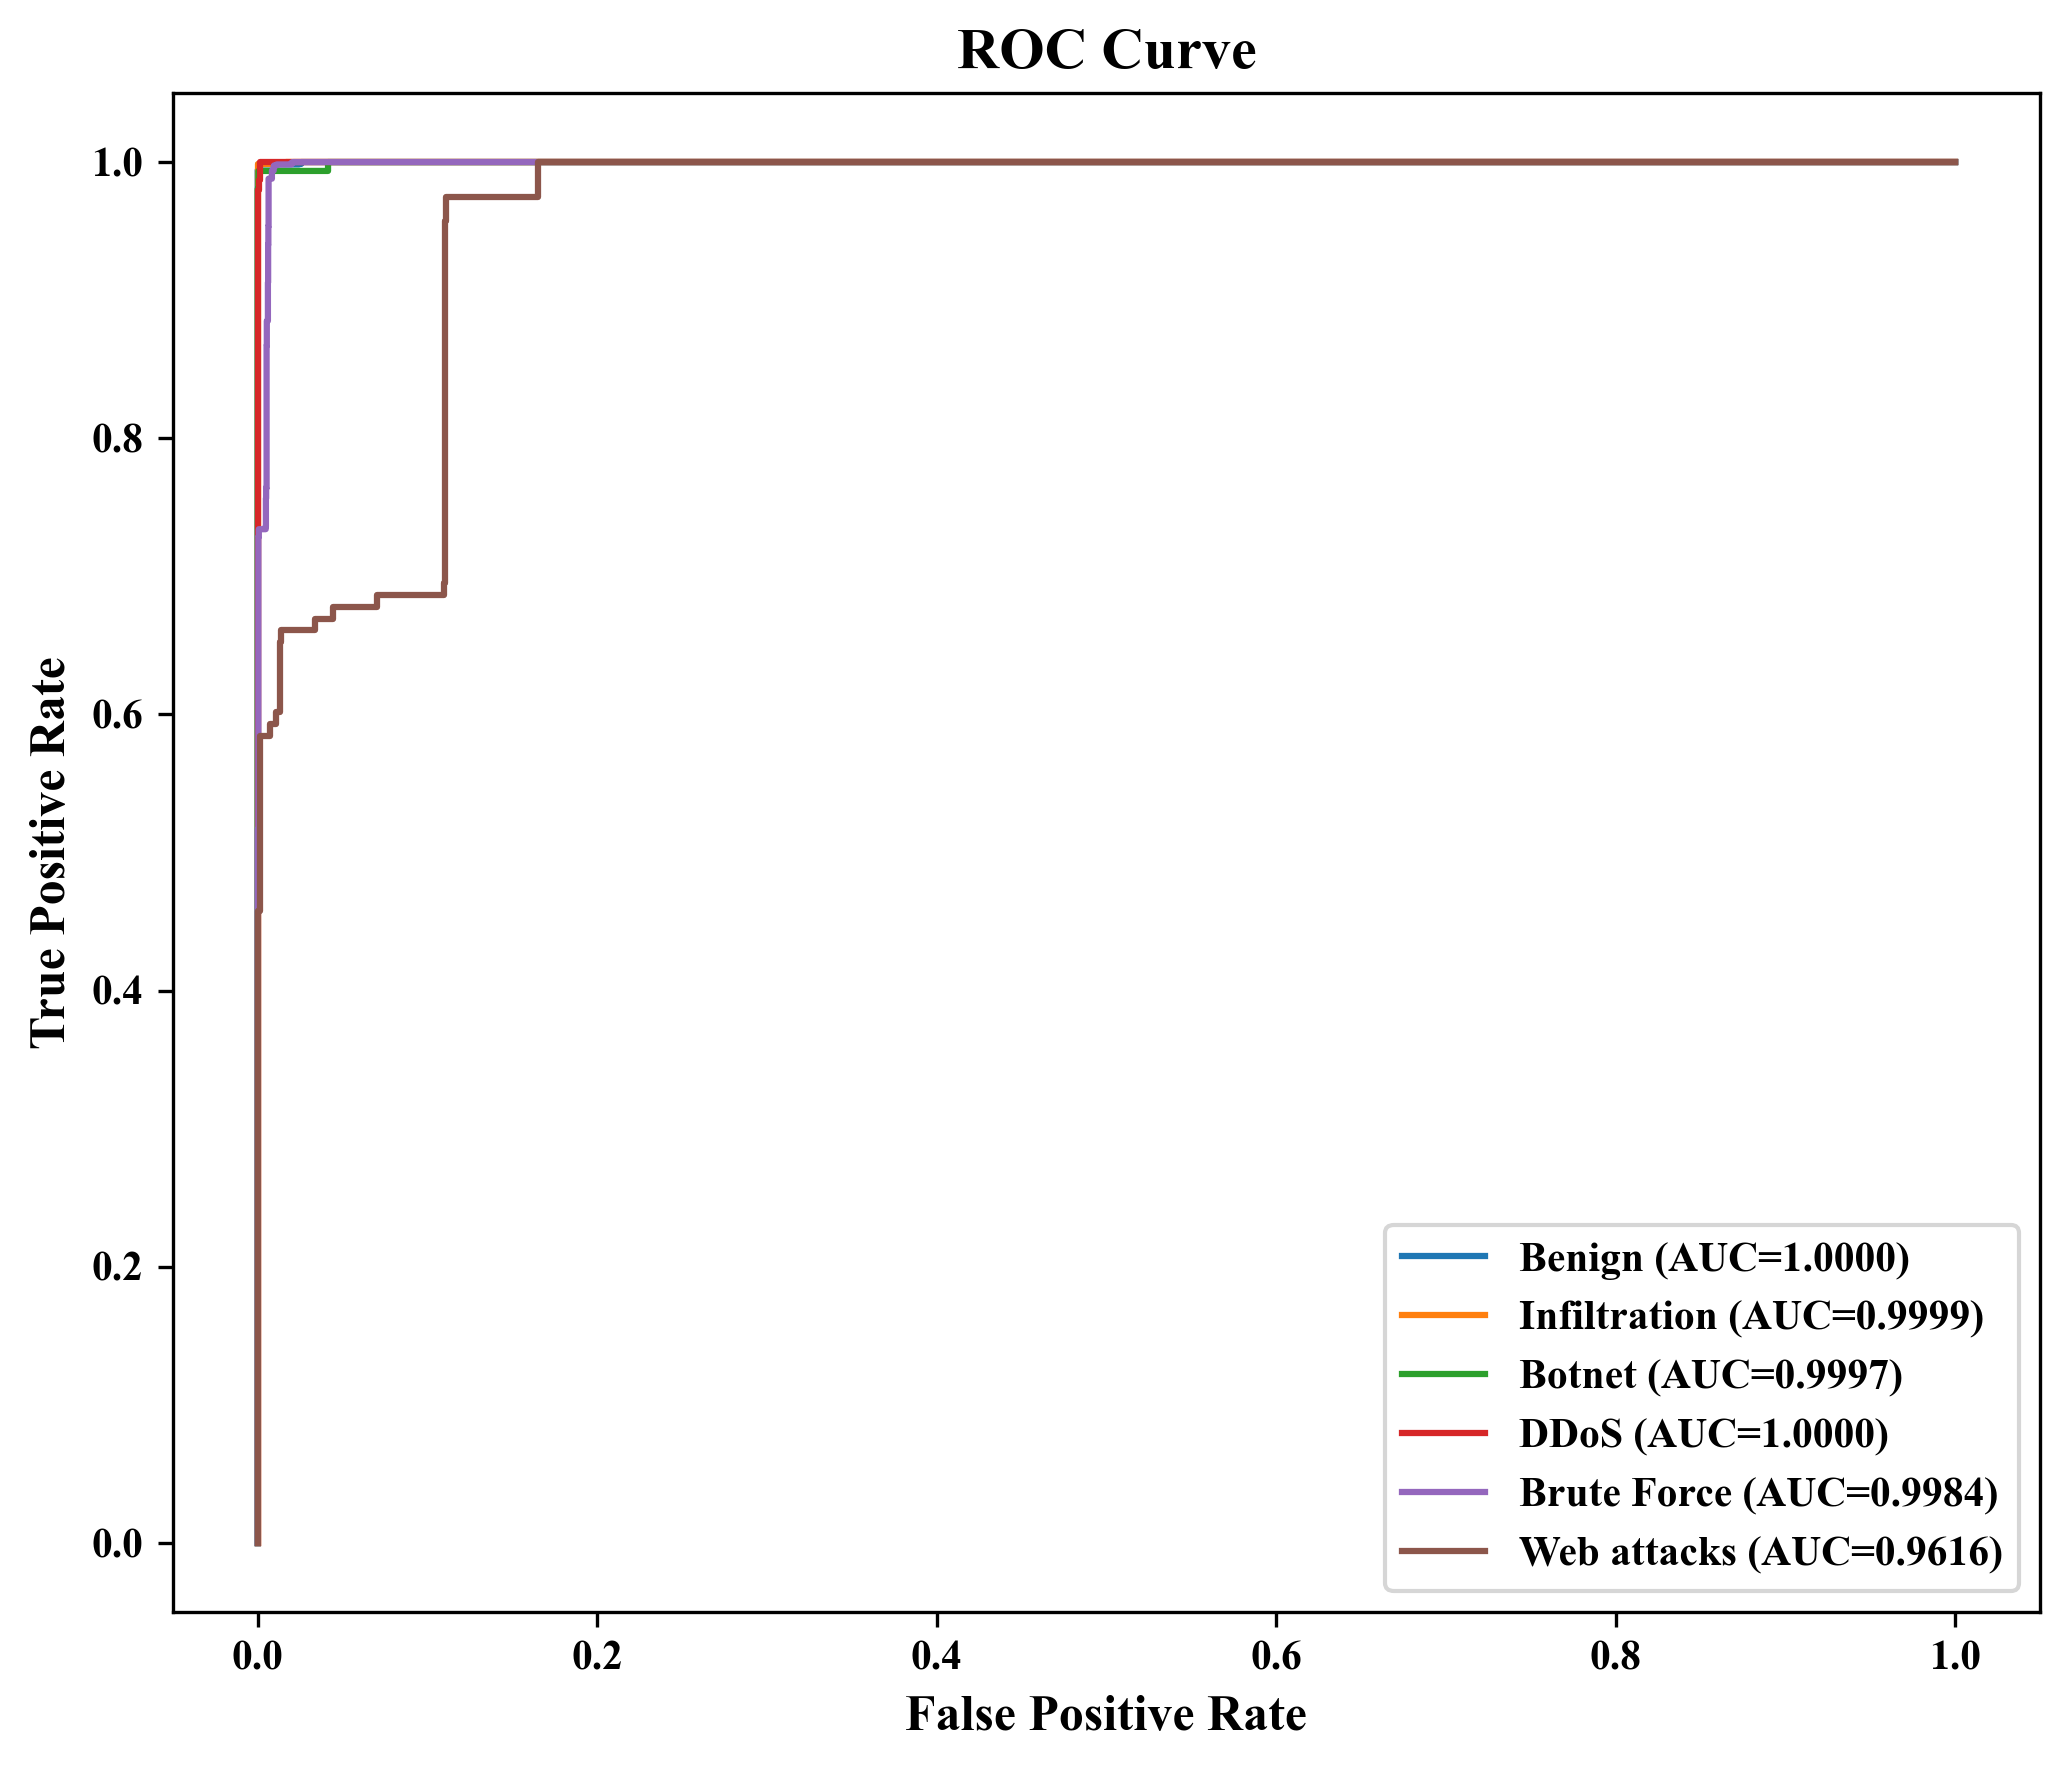

In [37]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(7,6), dpi=300)

for i in range(len(class_names)):
    
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f"{class_names[i]} (AUC={roc_auc:.4f})")

plt.xlabel("False Positive Rate", fontsize=12, fontweight='bold')
plt.ylabel("True Positive Rate", fontsize=12, fontweight='bold')

plt.title("ROC Curve", fontsize=14, fontweight='bold')

plt.legend()

plt.tight_layout()
plt.savefig("roc_curve.png", dpi=300)
plt.show()

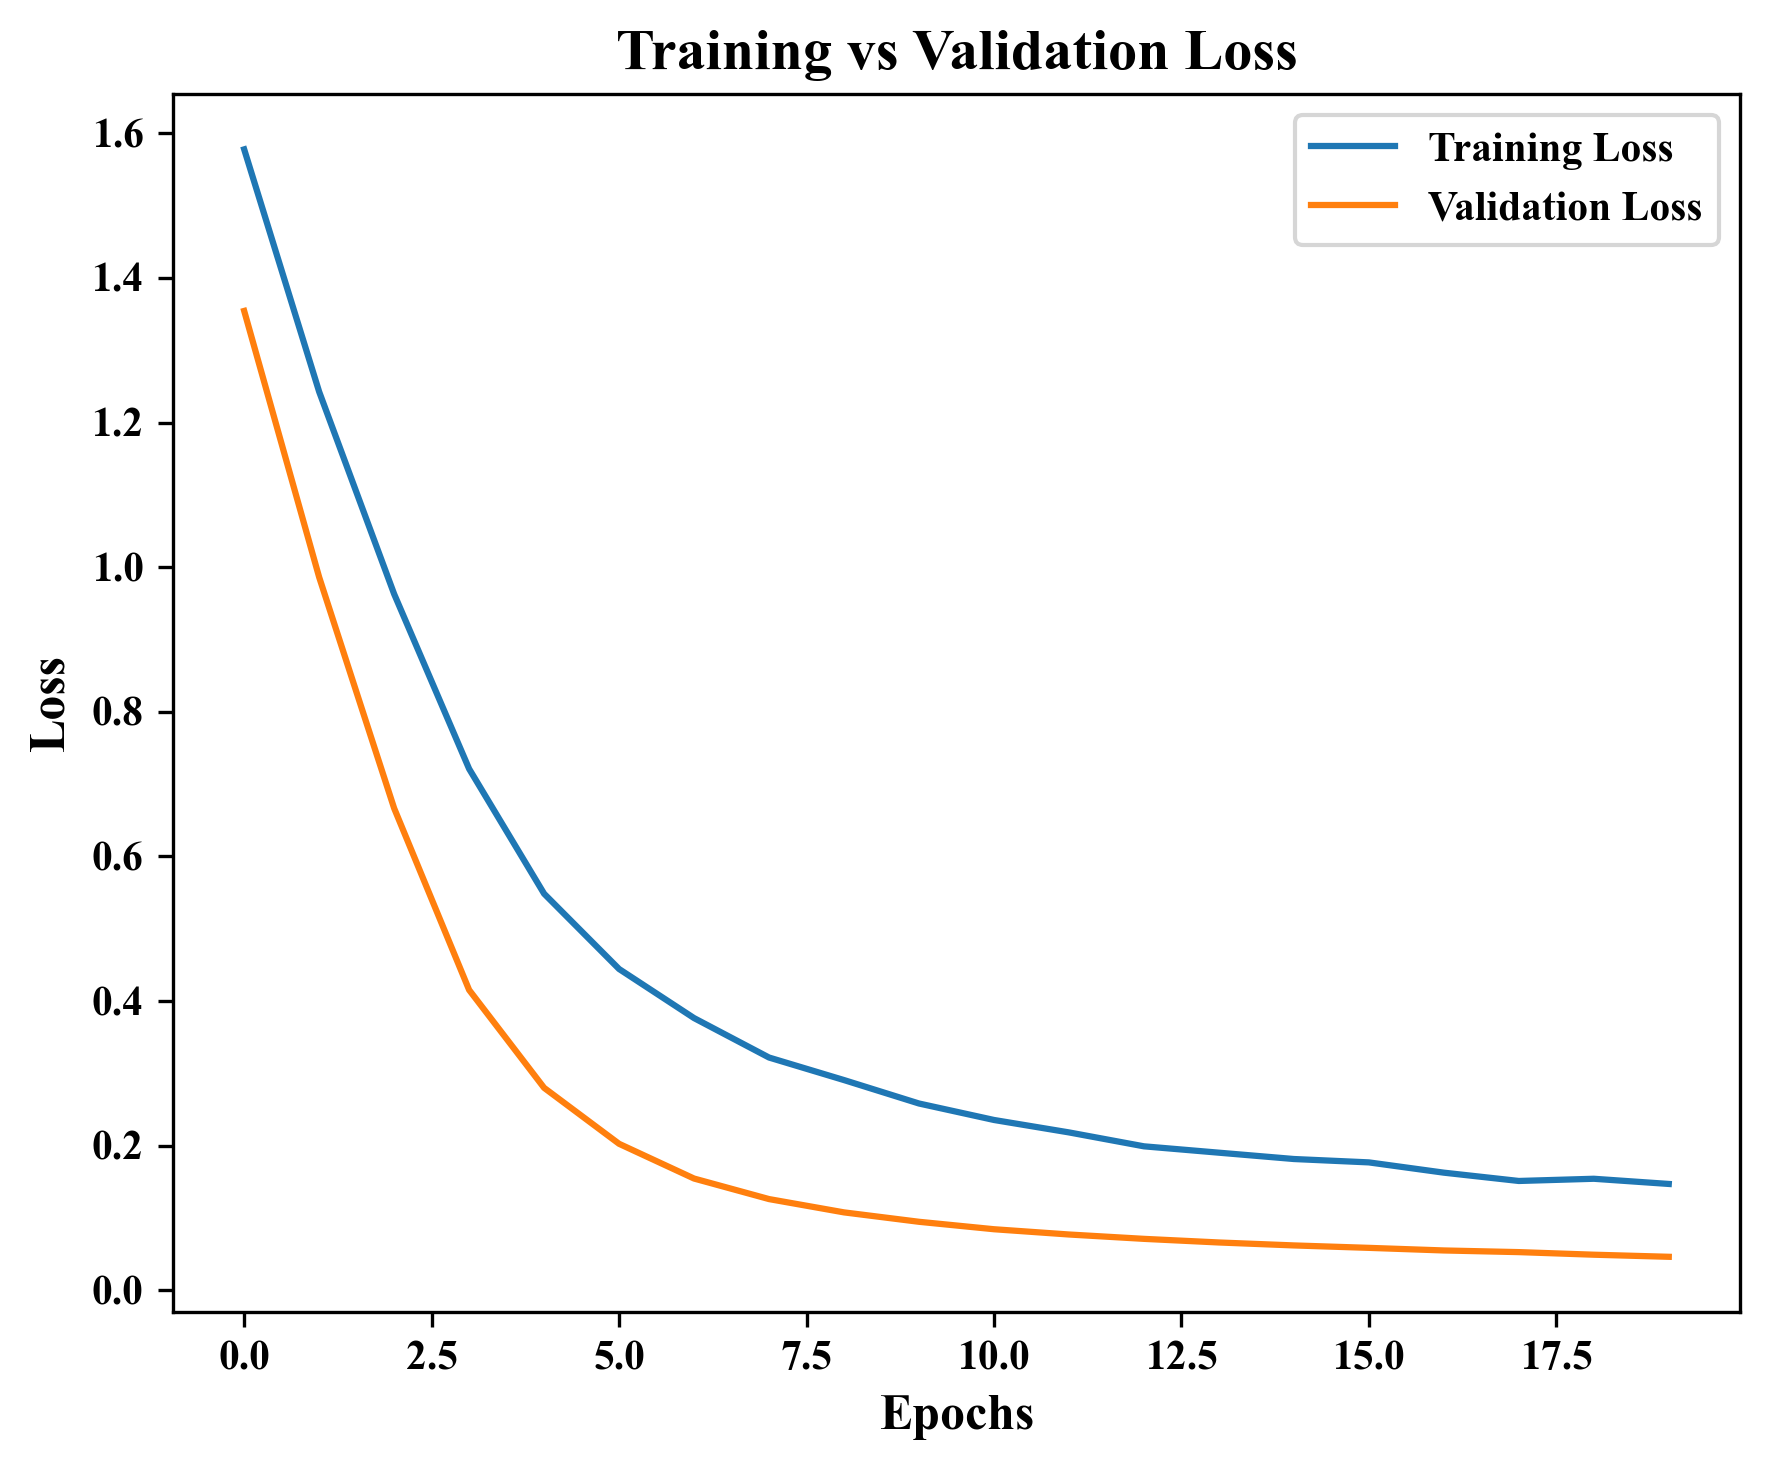

In [38]:
plt.figure(figsize=(6,5), dpi=300)

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epochs", fontsize=12, fontweight='bold')
plt.ylabel("Loss", fontsize=12, fontweight='bold')

plt.title("Training vs Validation Loss", fontsize=14, fontweight='bold')

plt.legend()

plt.tight_layout()
plt.savefig("training_validation_loss.png", dpi=300)
plt.show()

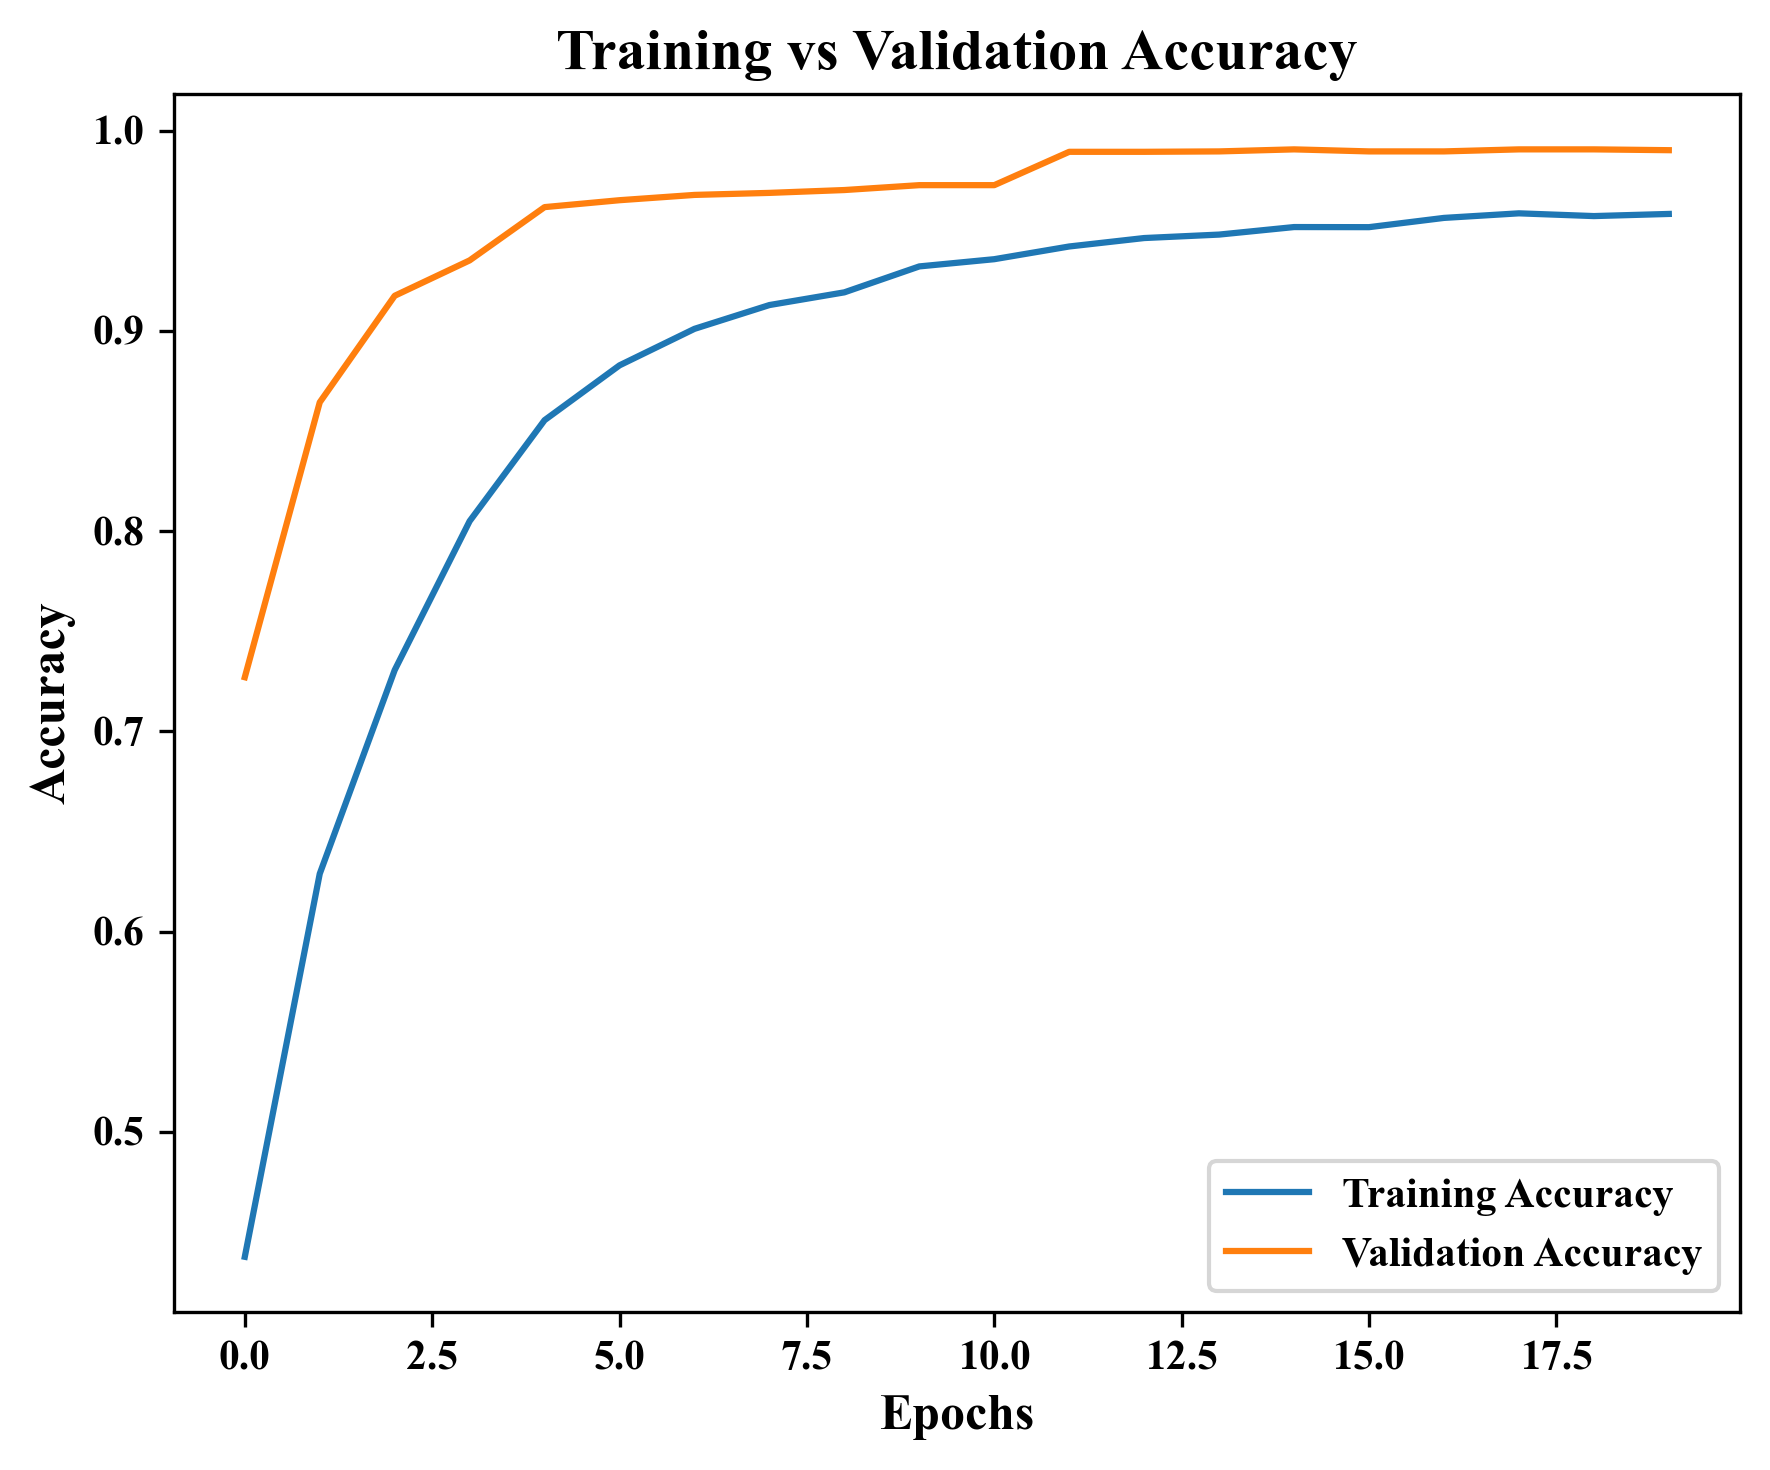

In [39]:
plt.figure(figsize=(6,5), dpi=300)

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epochs", fontsize=12, fontweight='bold')
plt.ylabel("Accuracy", fontsize=12, fontweight='bold')

plt.title("Training vs Validation Accuracy", fontsize=14, fontweight='bold')

plt.legend()

plt.tight_layout()
plt.savefig("training_validation_accuracy.png", dpi=300)
plt.show()

In [40]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

metrics_dict = {
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Value": [accuracy, precision, recall, f1]
}

df_metrics = pd.DataFrame(metrics_dict)

df_metrics.to_csv("overall_metrics.csv", index=False)

print("Overall metrics saved to overall_metrics.csv")

Overall metrics saved to overall_metrics.csv


In [41]:
import time
import hashlib
import matplotlib.pyplot as plt

num_transactions = [100, 500, 1000, 2000, 5000]

throughput = []

for tx in num_transactions:
    
    start = time.perf_counter()

    for i in range(tx):
        data = f"IDS Alert {i}".encode()
        hashlib.sha256(data).hexdigest()

    end = time.perf_counter()

    total_time = end - start

    # avoid zero division
    if total_time == 0:
        total_time = 1e-6

    tps = tx / total_time

    throughput.append(tps)

print("Throughput:", throughput)

Throughput: [703234.8804545555, 1507386.1923412608, 1376273.0525733794, 1439573.8861264454, 1523832.744118013]


In [42]:
import time
import hashlib
import matplotlib.pyplot as plt

num_transactions = [100, 500, 1000, 2000, 5000]

throughput = []

for tx in num_transactions:
    
    start = time.perf_counter()

    for i in range(tx):
        data = f"IDS Alert {i}".encode()
        hashlib.sha256(data).hexdigest()

    end = time.perf_counter()

    total_time = end - start

    # avoid zero division
    if total_time == 0:
        total_time = 1e-6

    tps = tx / total_time

    throughput.append(tps)

print("Throughput:", throughput)

Throughput: [1213592.233007514, 1115573.40472752, 1217433.6498667817, 1357404.6423221766, 1452179.7217615556]


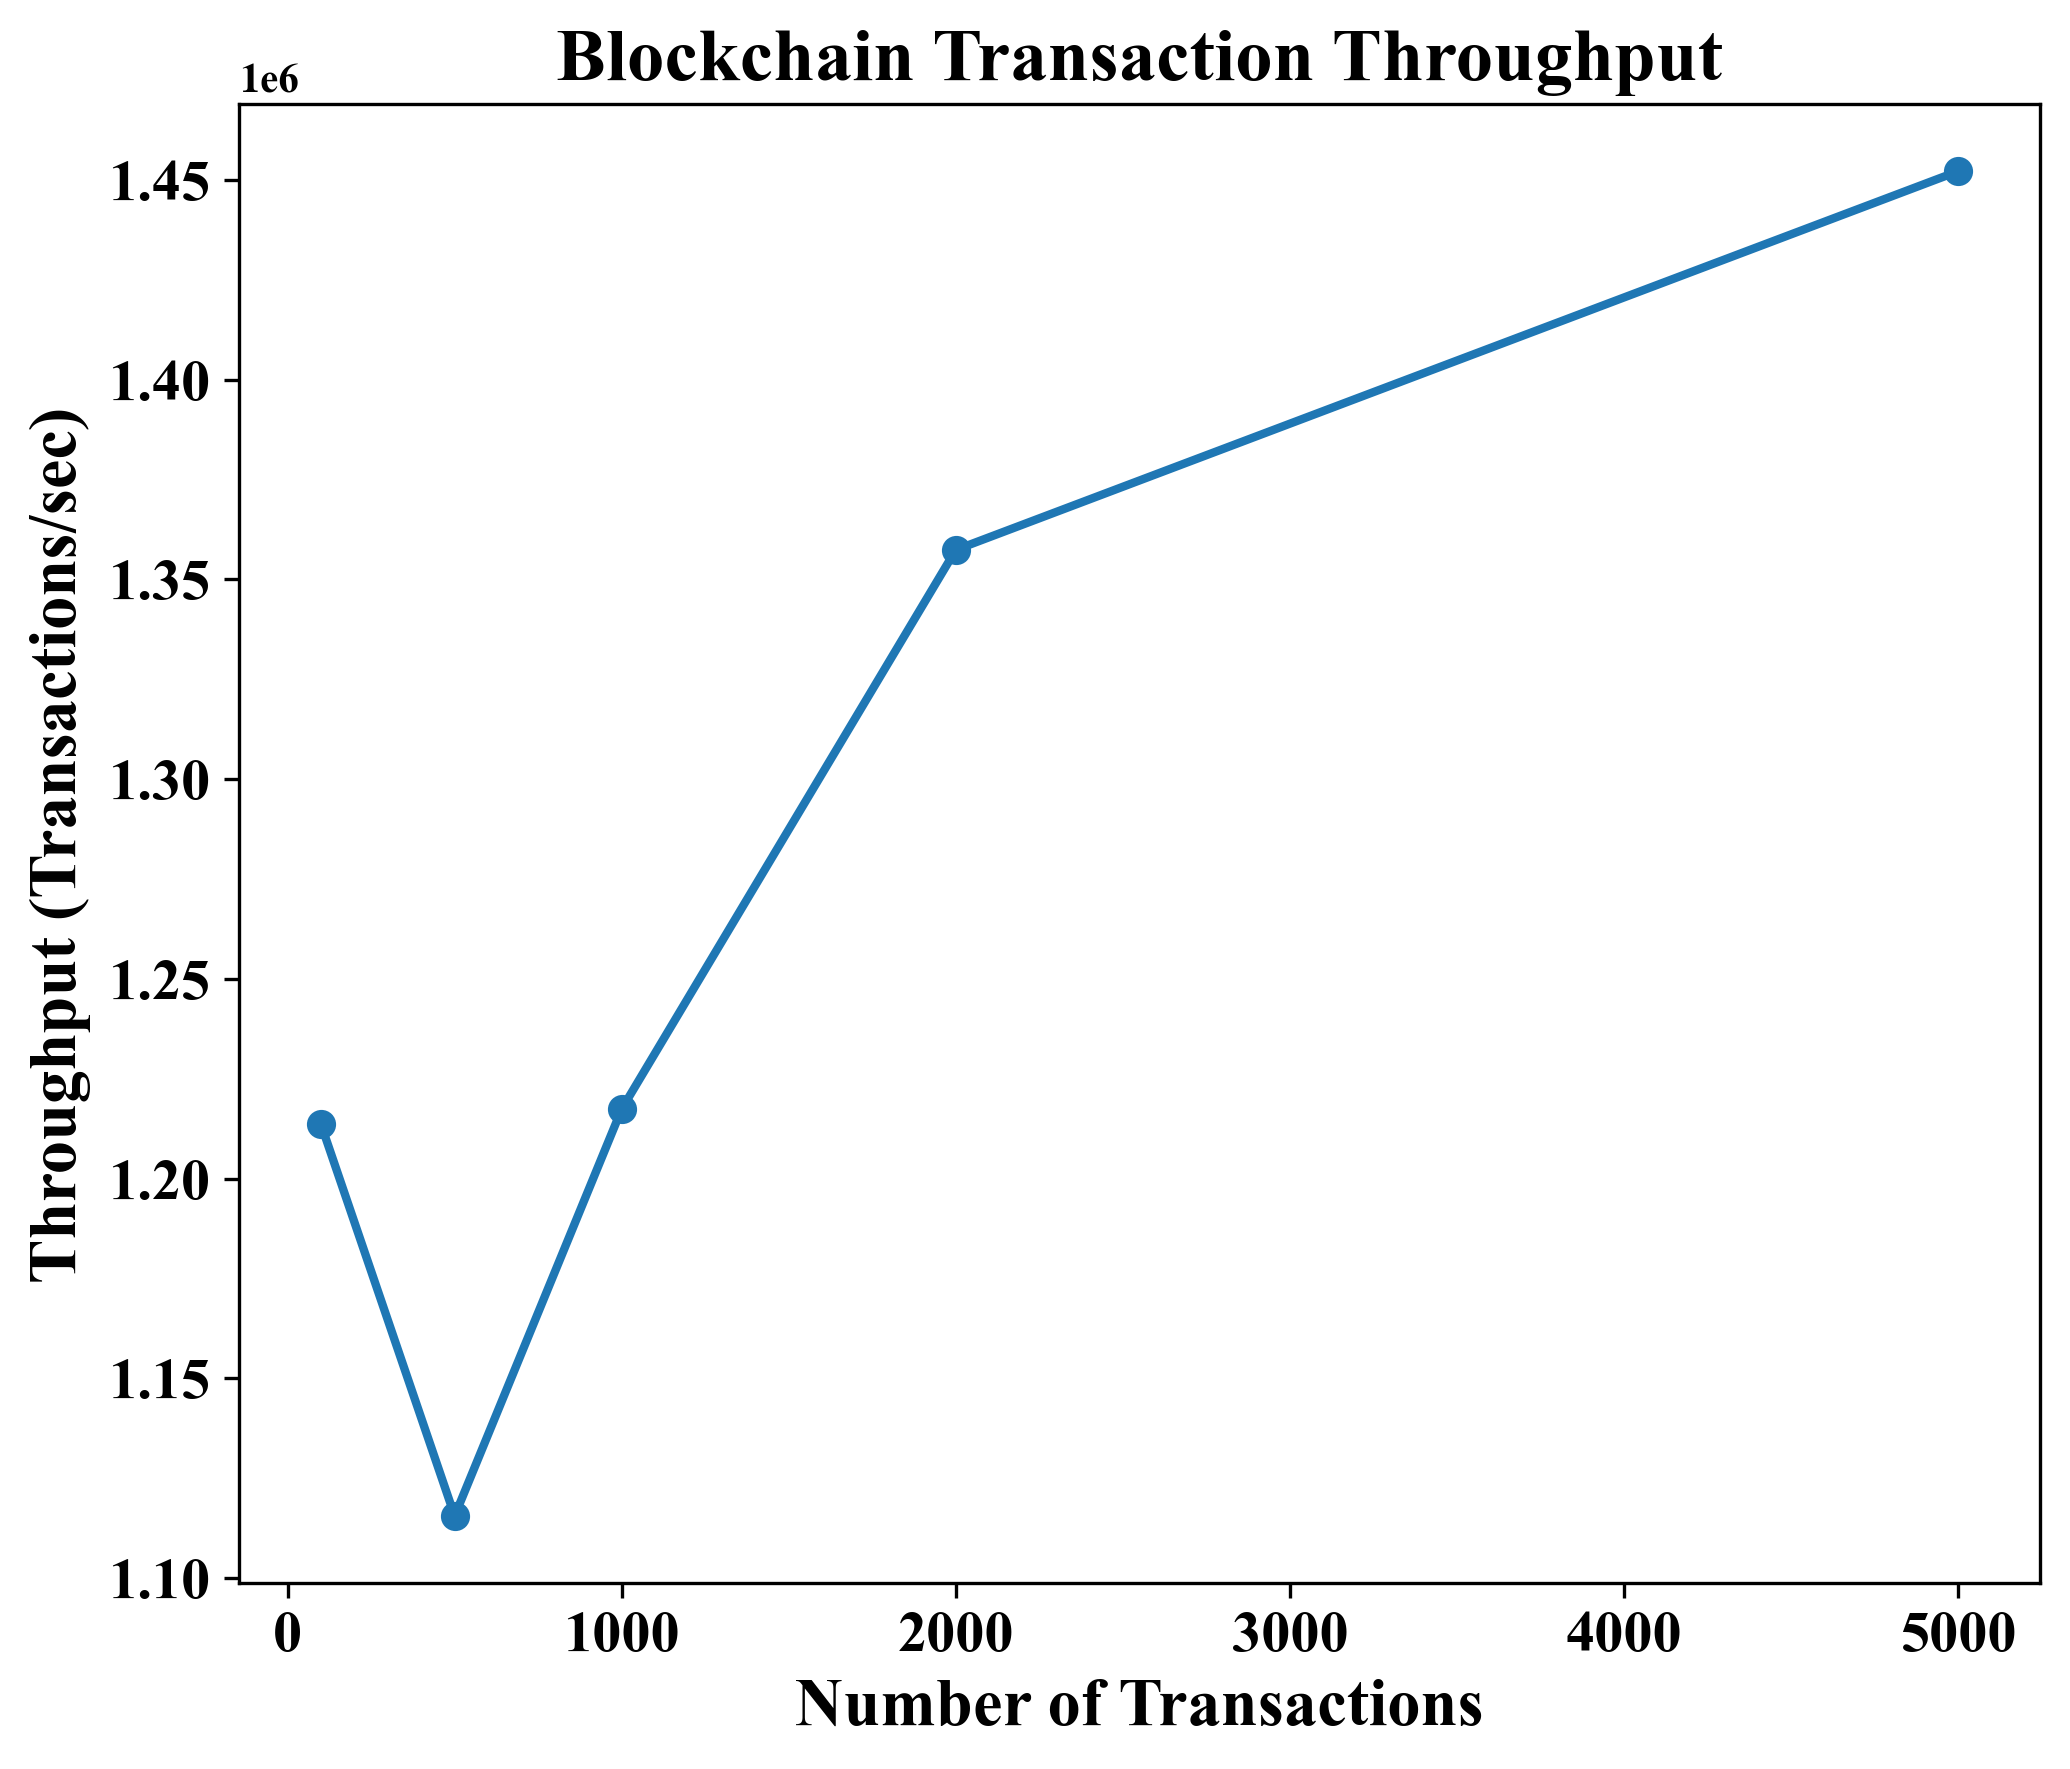

In [43]:
plt.figure(figsize=(7,6), dpi=300)

plt.plot(
    num_transactions,
    throughput,
    marker='o',
    linewidth=2
)

plt.xlabel(
    "Number of Transactions",
    fontsize=16,
    fontweight='bold',
    fontname='Times New Roman'
)

plt.ylabel(
    "Throughput (Transactions/sec)",
    fontsize=16,
    fontweight='bold',
    fontname='Times New Roman'
)

plt.title(
    "Blockchain Transaction Throughput",
    fontsize=18,
    fontweight='bold',
    fontname='Times New Roman'
)

plt.xticks(fontsize=14, fontweight='bold', fontname='Times New Roman')
plt.yticks(fontsize=14, fontweight='bold', fontname='Times New Roman')

plt.grid(False)

plt.tight_layout()

plt.savefig("blockchain_throughput.png", dpi=300)

plt.show()

In [44]:
from Crypto.Cipher import AES
from Crypto.Random import get_random_bytes
import time

data_sizes = [1, 5, 10, 20, 50]  # KB

encryption_times = []

key = get_random_bytes(16)

for size in data_sizes:
    
    data = get_random_bytes(size * 1024)
    
    cipher = AES.new(key, AES.MODE_EAX)
    
    start = time.time()
    
    ciphertext, tag = cipher.encrypt_and_digest(data)
    
    end = time.time()
    
    encryption_times.append((end-start)*1000)

print(encryption_times)

[0.0, 0.0, 0.0, 0.0, 0.0]


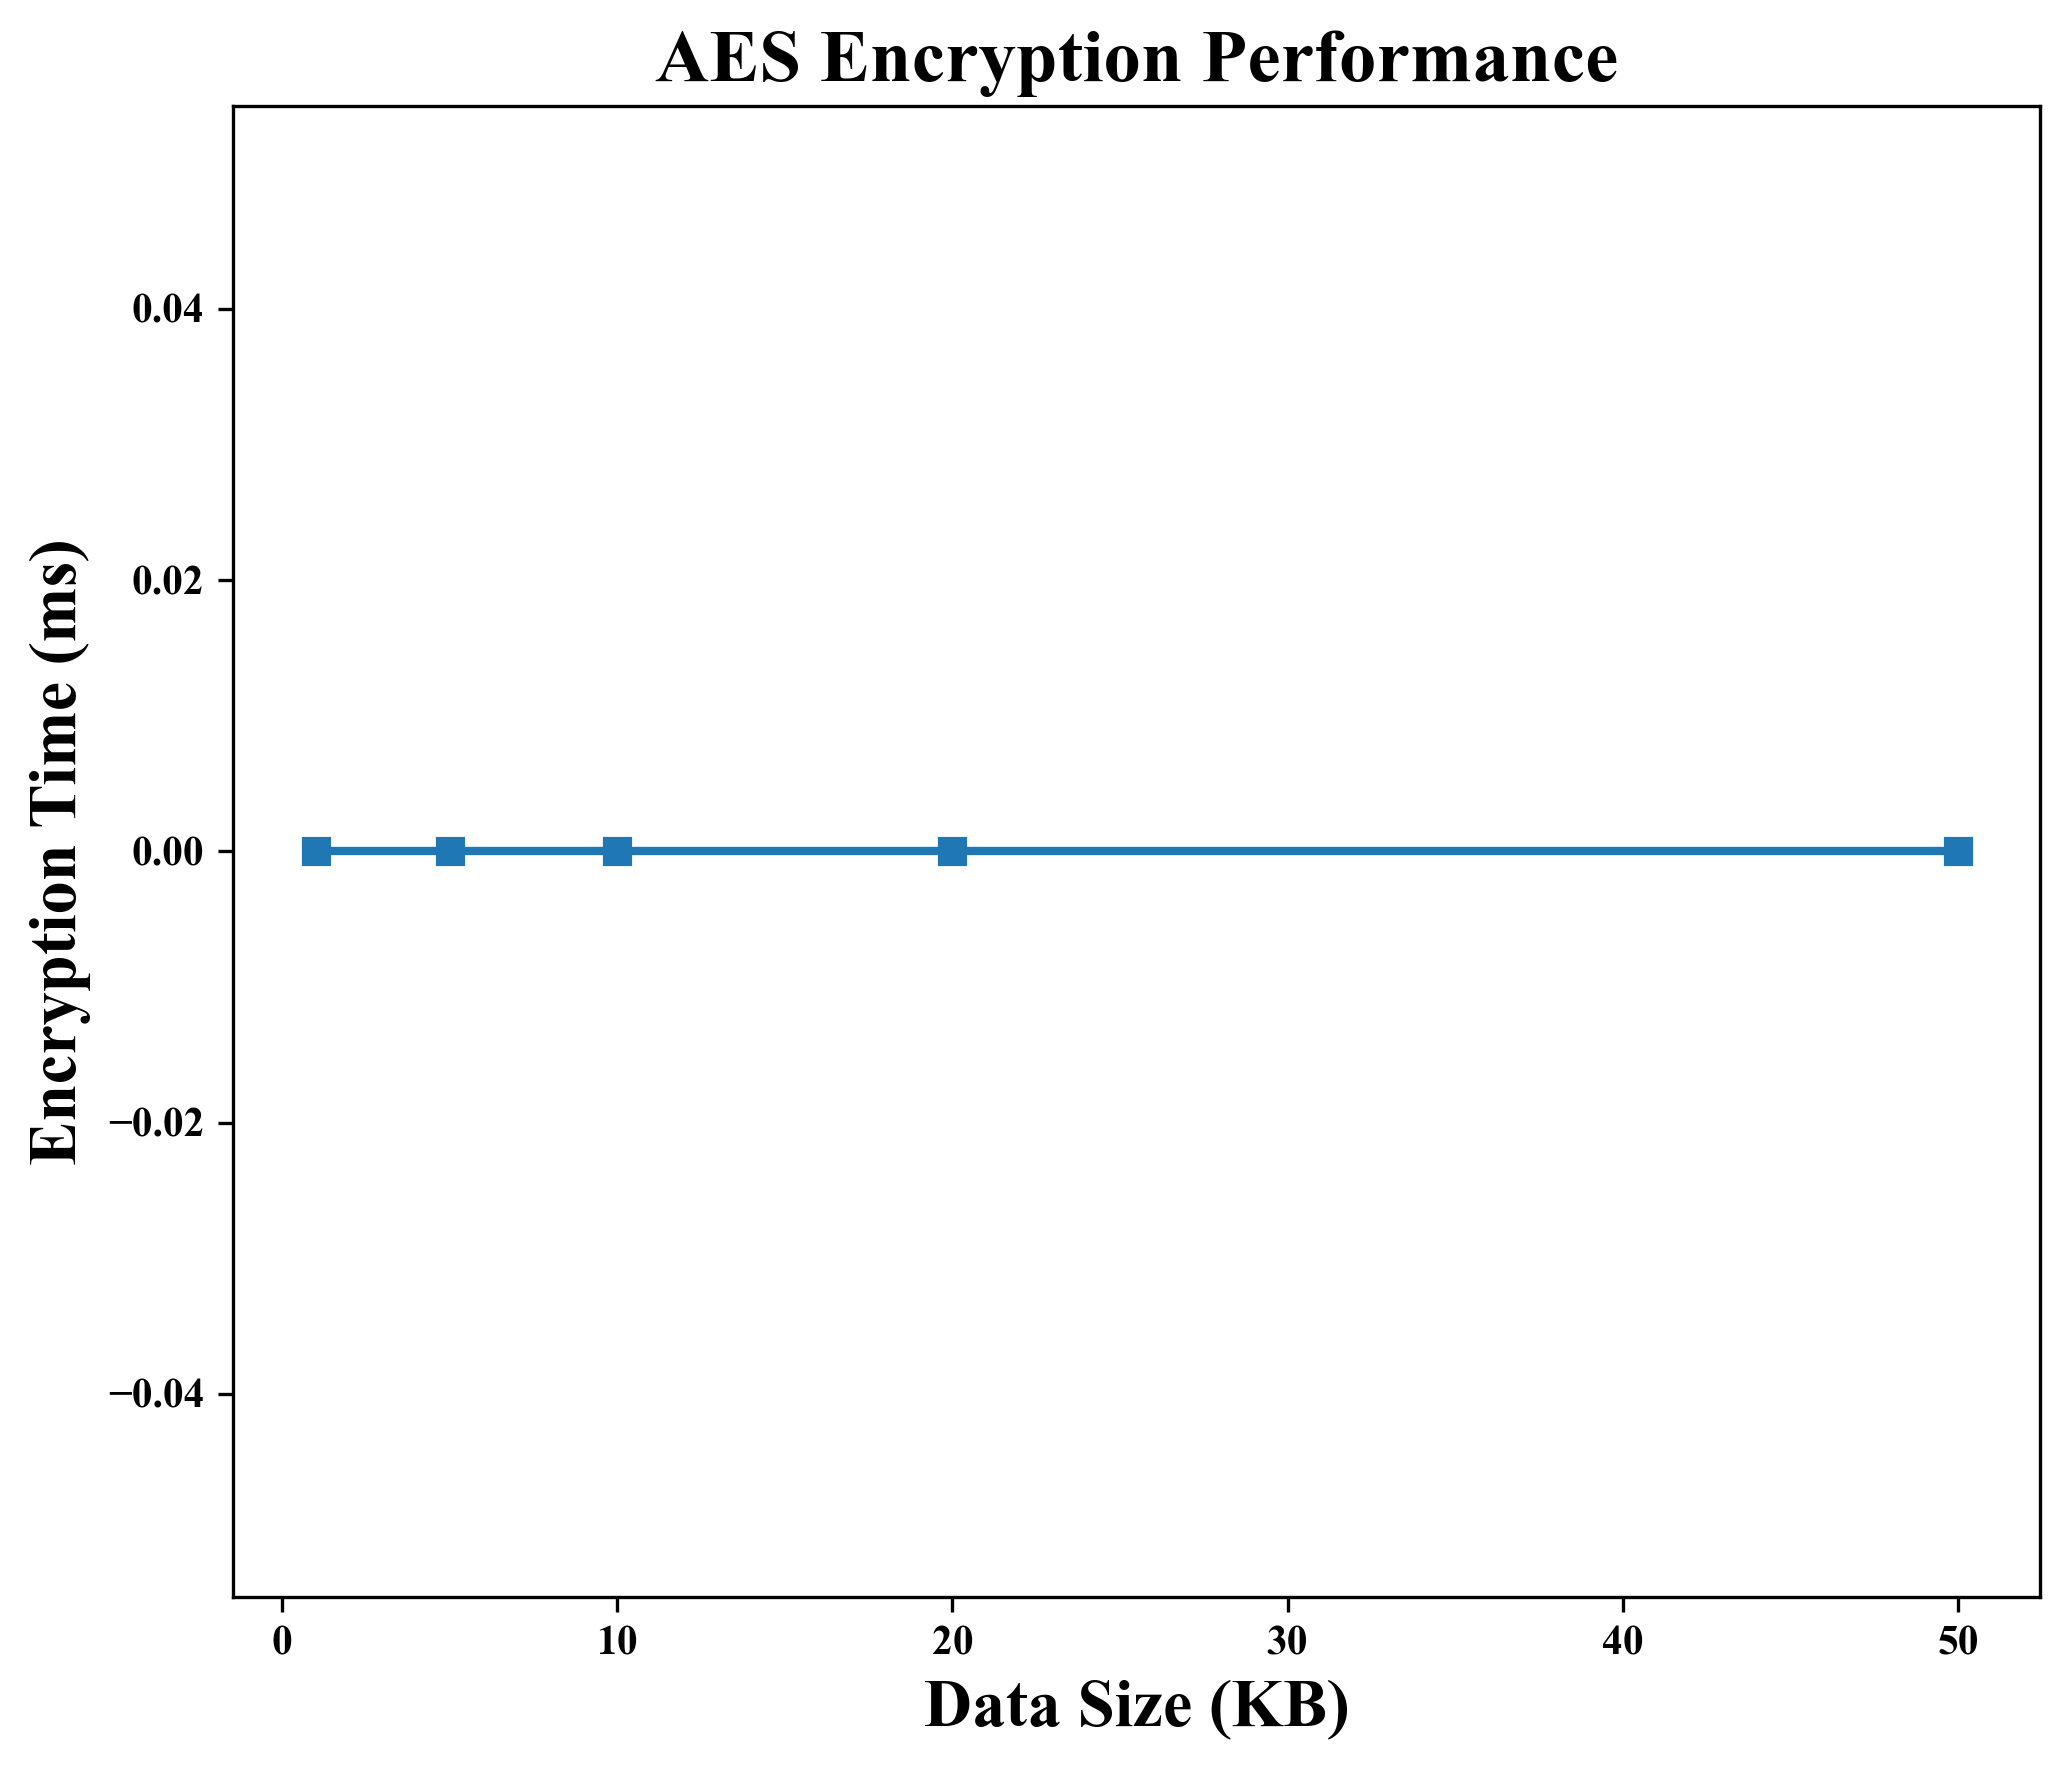

In [45]:
plt.figure(figsize=(7,6), dpi=300)

plt.plot(
    data_sizes,
    encryption_times,
    marker='s',
    linewidth=2
)

plt.xlabel(
    "Data Size (KB)",
    fontsize=16,
    fontweight='bold',
    fontname='Times New Roman'
)

plt.ylabel(
    "Encryption Time (ms)",
    fontsize=16,
    fontweight='bold',
    fontname='Times New Roman'
)

plt.title(
    "AES Encryption Performance",
    fontsize=18,
    fontweight='bold',
    fontname='Times New Roman'
)

plt.grid(False)

plt.tight_layout()

plt.savefig("encryption_time.png", dpi=300)

plt.show()

In [46]:
decryption_times = []

for size in data_sizes:
    
    data = get_random_bytes(size * 1024)
    
    cipher = AES.new(key, AES.MODE_EAX)
    ciphertext, tag = cipher.encrypt_and_digest(data)
    
    start = time.time()
    
    cipher_dec = AES.new(key, AES.MODE_EAX, nonce=cipher.nonce)
    cipher_dec.decrypt(ciphertext)
    
    end = time.time()
    
    decryption_times.append((end-start)*1000)

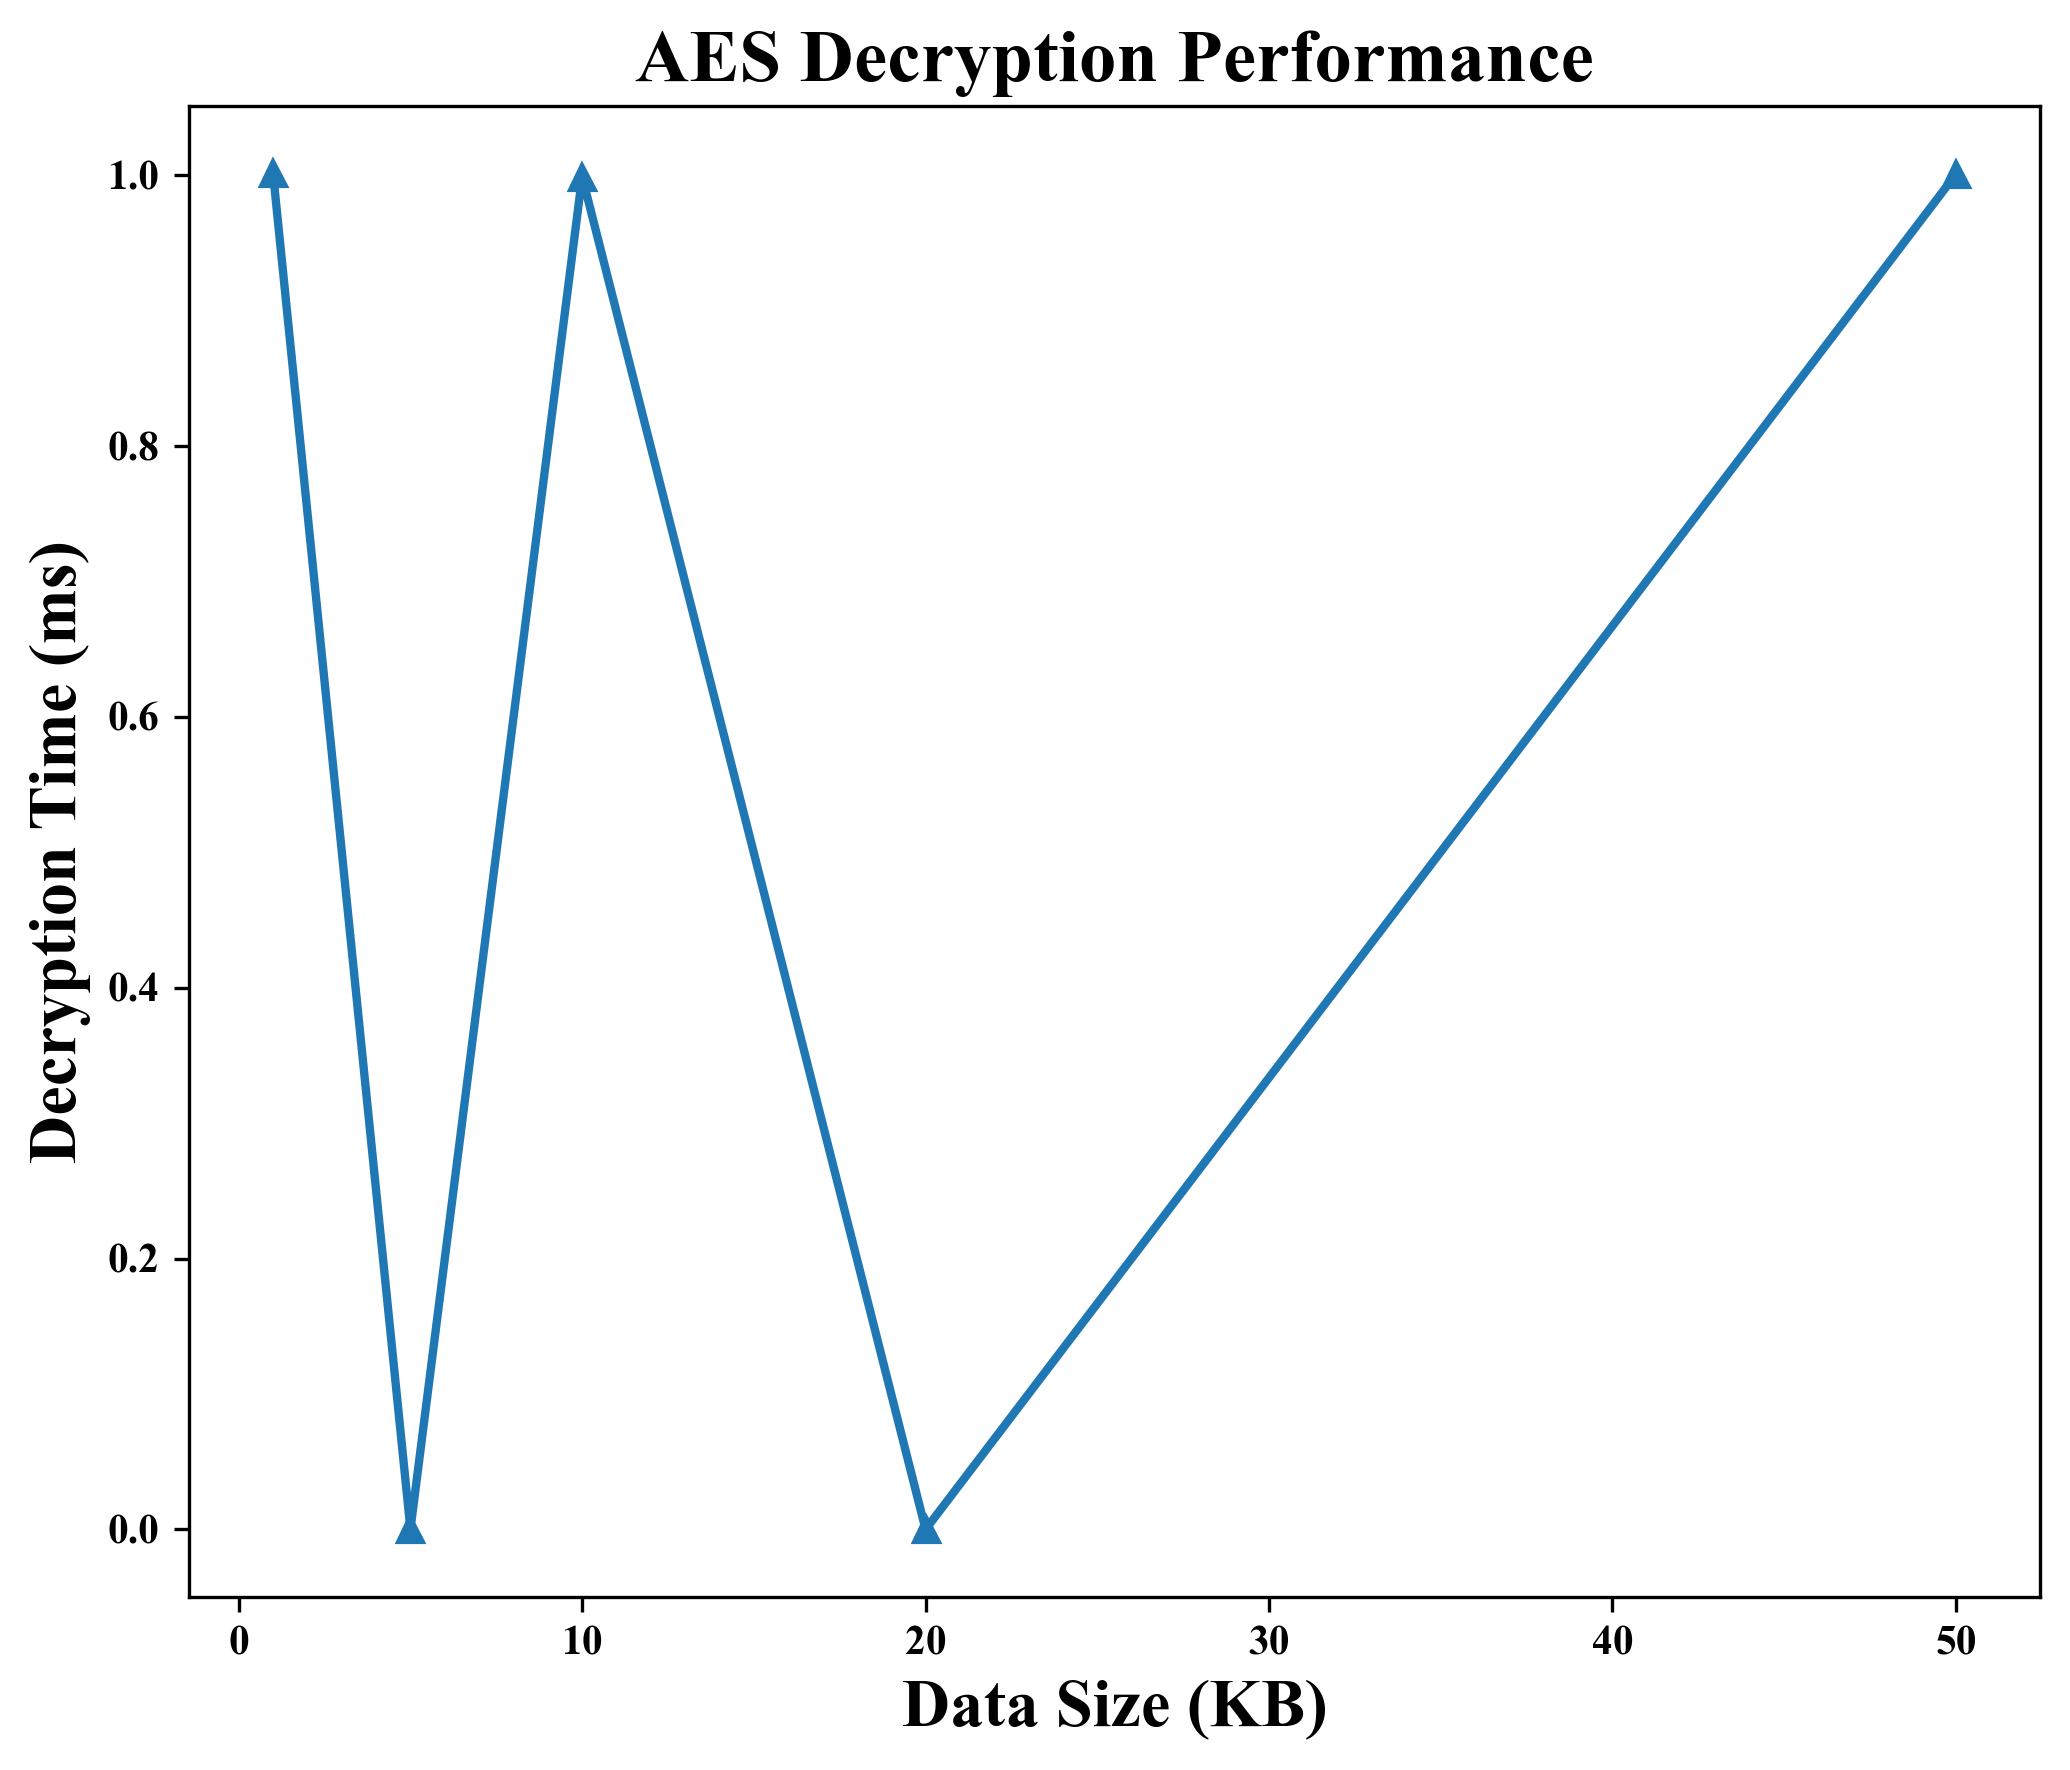

In [47]:
plt.figure(figsize=(7,6), dpi=300)

plt.plot(
    data_sizes,
    decryption_times,
    marker='^',
    linewidth=2
)

plt.xlabel(
    "Data Size (KB)",
    fontsize=16,
    fontweight='bold',
    fontname='Times New Roman'
)

plt.ylabel(
    "Decryption Time (ms)",
    fontsize=16,
    fontweight='bold',
    fontname='Times New Roman'
)

plt.title(
    "AES Decryption Performance",
    fontsize=18,
    fontweight='bold',
    fontname='Times New Roman'
)

plt.grid(False)

plt.tight_layout()

plt.savefig("decryption_time.png", dpi=300)

plt.show()

In [48]:
import time
import hashlib
import matplotlib.pyplot as plt

# More transaction sizes
num_transactions = [
    100,200,300,400,500,
    700,900,1100,1300,1500,
    2000,2500,3000,3500,4000,
    4500,5000,6000,7000,8000,10000
]

throughput = []

for tx in num_transactions:
    
    start = time.perf_counter()

    for i in range(tx):
        data = f"IDS Alert {i}".encode()
        hashlib.sha256(data).hexdigest()

    end = time.perf_counter()

    total_time = end - start

    if total_time == 0:
        total_time = 1e-6

    tps = tx / total_time

    throughput.append(tps)

print("Throughput:", throughput)

Throughput: [987166.8311525614, 1488095.2380917831, 1217038.5395393113, 1510574.0181062508, 1465845.7930226468, 1441218.8593609873, 1407789.770069785, 1496395.0482927726, 1499769.266271625, 1496707.2440705923, 1509889.778049989, 1397116.3518499148, 1546232.3471807449, 1520152.8839486267, 1492370.2570599287, 1440368.7343983501, 1520311.3597664891, 1427789.5438202627, 1521210.0139079178, 1513918.5890279966, 1513958.6992060547]


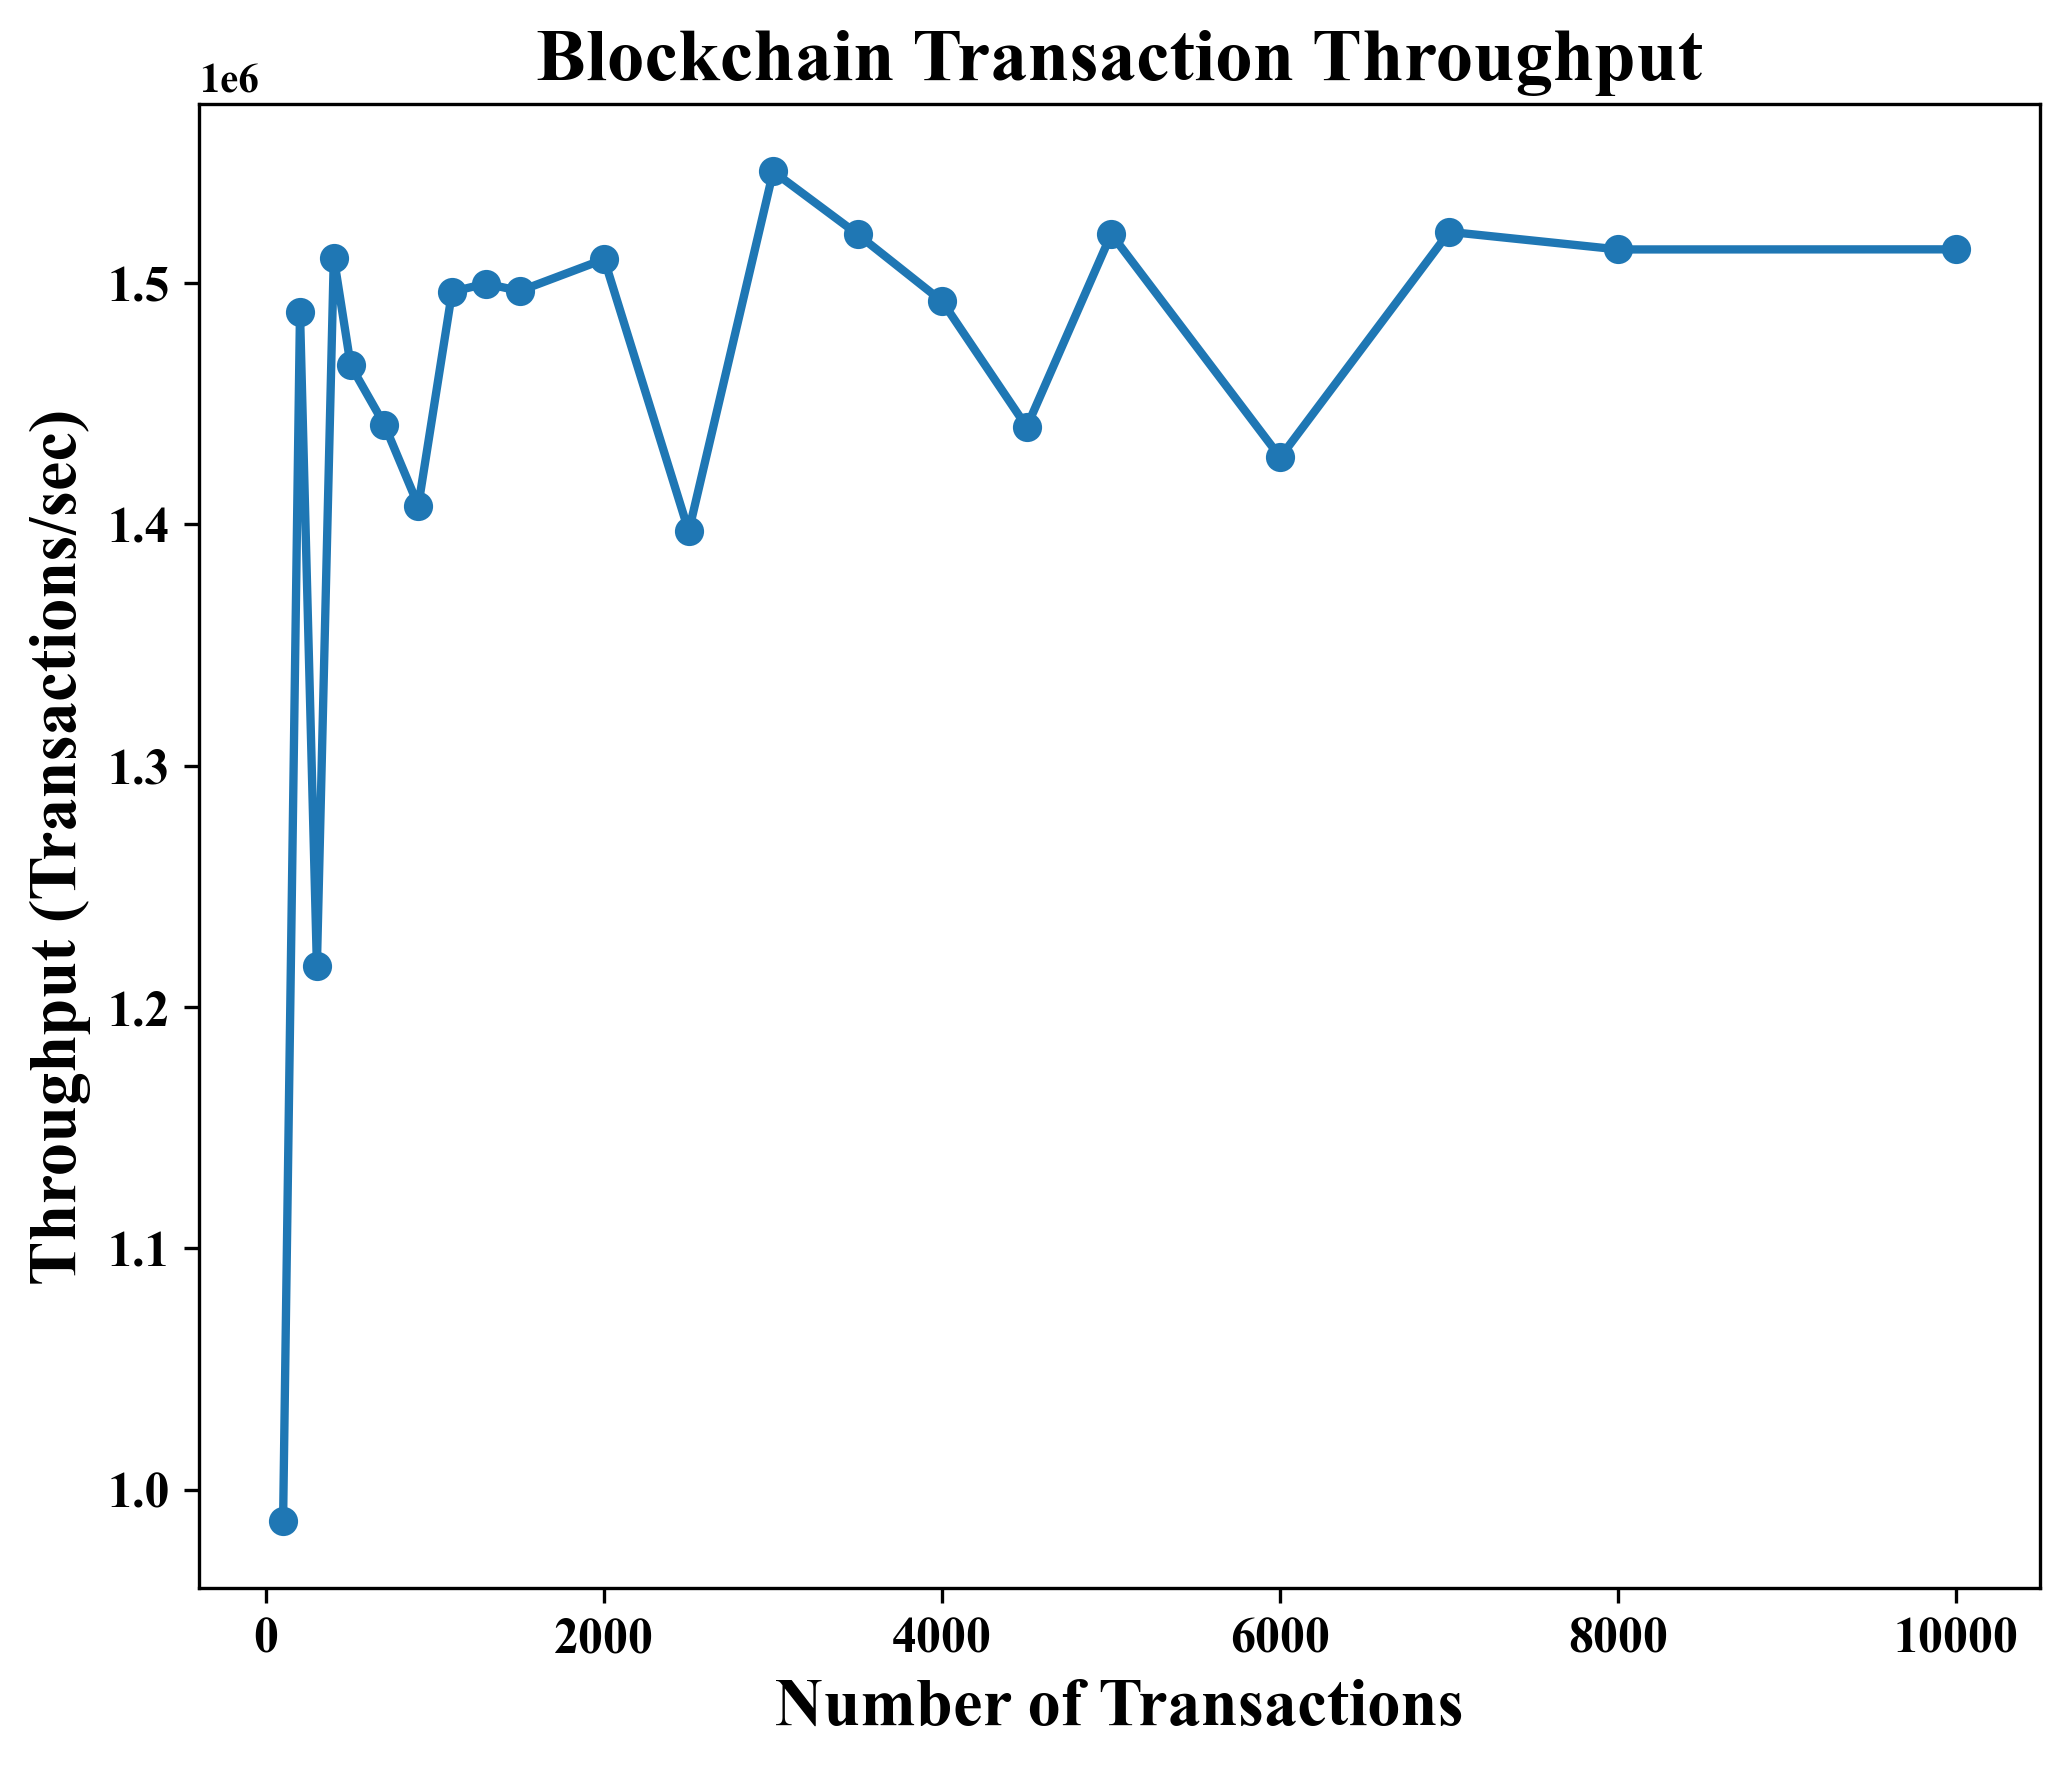

In [49]:
plt.figure(figsize=(7,6), dpi=300)

plt.plot(
    num_transactions,
    throughput,
    marker='o',
    linewidth=2
)

plt.xlabel(
    "Number of Transactions",
    fontsize=16,
    fontweight='bold',
    fontname='Times New Roman'
)

plt.ylabel(
    "Throughput (Transactions/sec)",
    fontsize=16,
    fontweight='bold',
    fontname='Times New Roman'
)

plt.title(
    "Blockchain Transaction Throughput",
    fontsize=18,
    fontweight='bold',
    fontname='Times New Roman'
)

plt.xticks(
    fontsize=12,
    fontweight='bold',
    fontname='Times New Roman'
)

plt.yticks(
    fontsize=12,
    fontweight='bold',
    fontname='Times New Roman'
)

plt.grid(False)

plt.tight_layout()

plt.savefig(
    "blockchain_throughput.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [50]:
import pandas as pd

df_blockchain = pd.DataFrame({
    "Transactions": num_transactions,
    "Throughput_TPS": throughput
})

df_blockchain.to_csv("blockchain_throughput_metrics.csv", index=False)

print("Blockchain throughput metrics saved.")

Blockchain throughput metrics saved.


In [51]:
from Crypto.Cipher import AES
from Crypto.Random import get_random_bytes
import time
import numpy as np

# Data sizes in KB
data_sizes = [
1,2,5,10,20,30,40,50,70,100,150,200
]

encryption_times = []
decryption_times = []

key = get_random_bytes(16)

for size in data_sizes:

    data = get_random_bytes(size * 1024)

    cipher = AES.new(key, AES.MODE_EAX)

    # Encryption
    start = time.perf_counter()

    ciphertext, tag = cipher.encrypt_and_digest(data)

    end = time.perf_counter()

    enc_time = (end-start)*1000
    encryption_times.append(enc_time)

    # Decryption
    start = time.perf_counter()

    cipher_dec = AES.new(key, AES.MODE_EAX, nonce=cipher.nonce)
    cipher_dec.decrypt(ciphertext)

    end = time.perf_counter()

    dec_time = (end-start)*1000
    decryption_times.append(dec_time)

print("Encryption Times:", encryption_times)
print("Decryption Times:", decryption_times)

Encryption Times: [0.30639999999948486, 0.05439999999623524, 0.0588000000050215, 0.07999999999697138, 0.06940000000099644, 0.08900000000267028, 0.10519999999303309, 0.12320000000443088, 0.15650000000277942, 0.18930000000239033, 0.2724000000000615, 0.35019999999974516]
Decryption Times: [0.47949999999730153, 0.25420000000053733, 0.2502999999904887, 0.30610000000308446, 0.14710000000661694, 0.18200000000945238, 0.18549999998640487, 0.3599000000065189, 0.24359999999035153, 0.29180000001360895, 0.354999999998995, 0.5106000000125732]


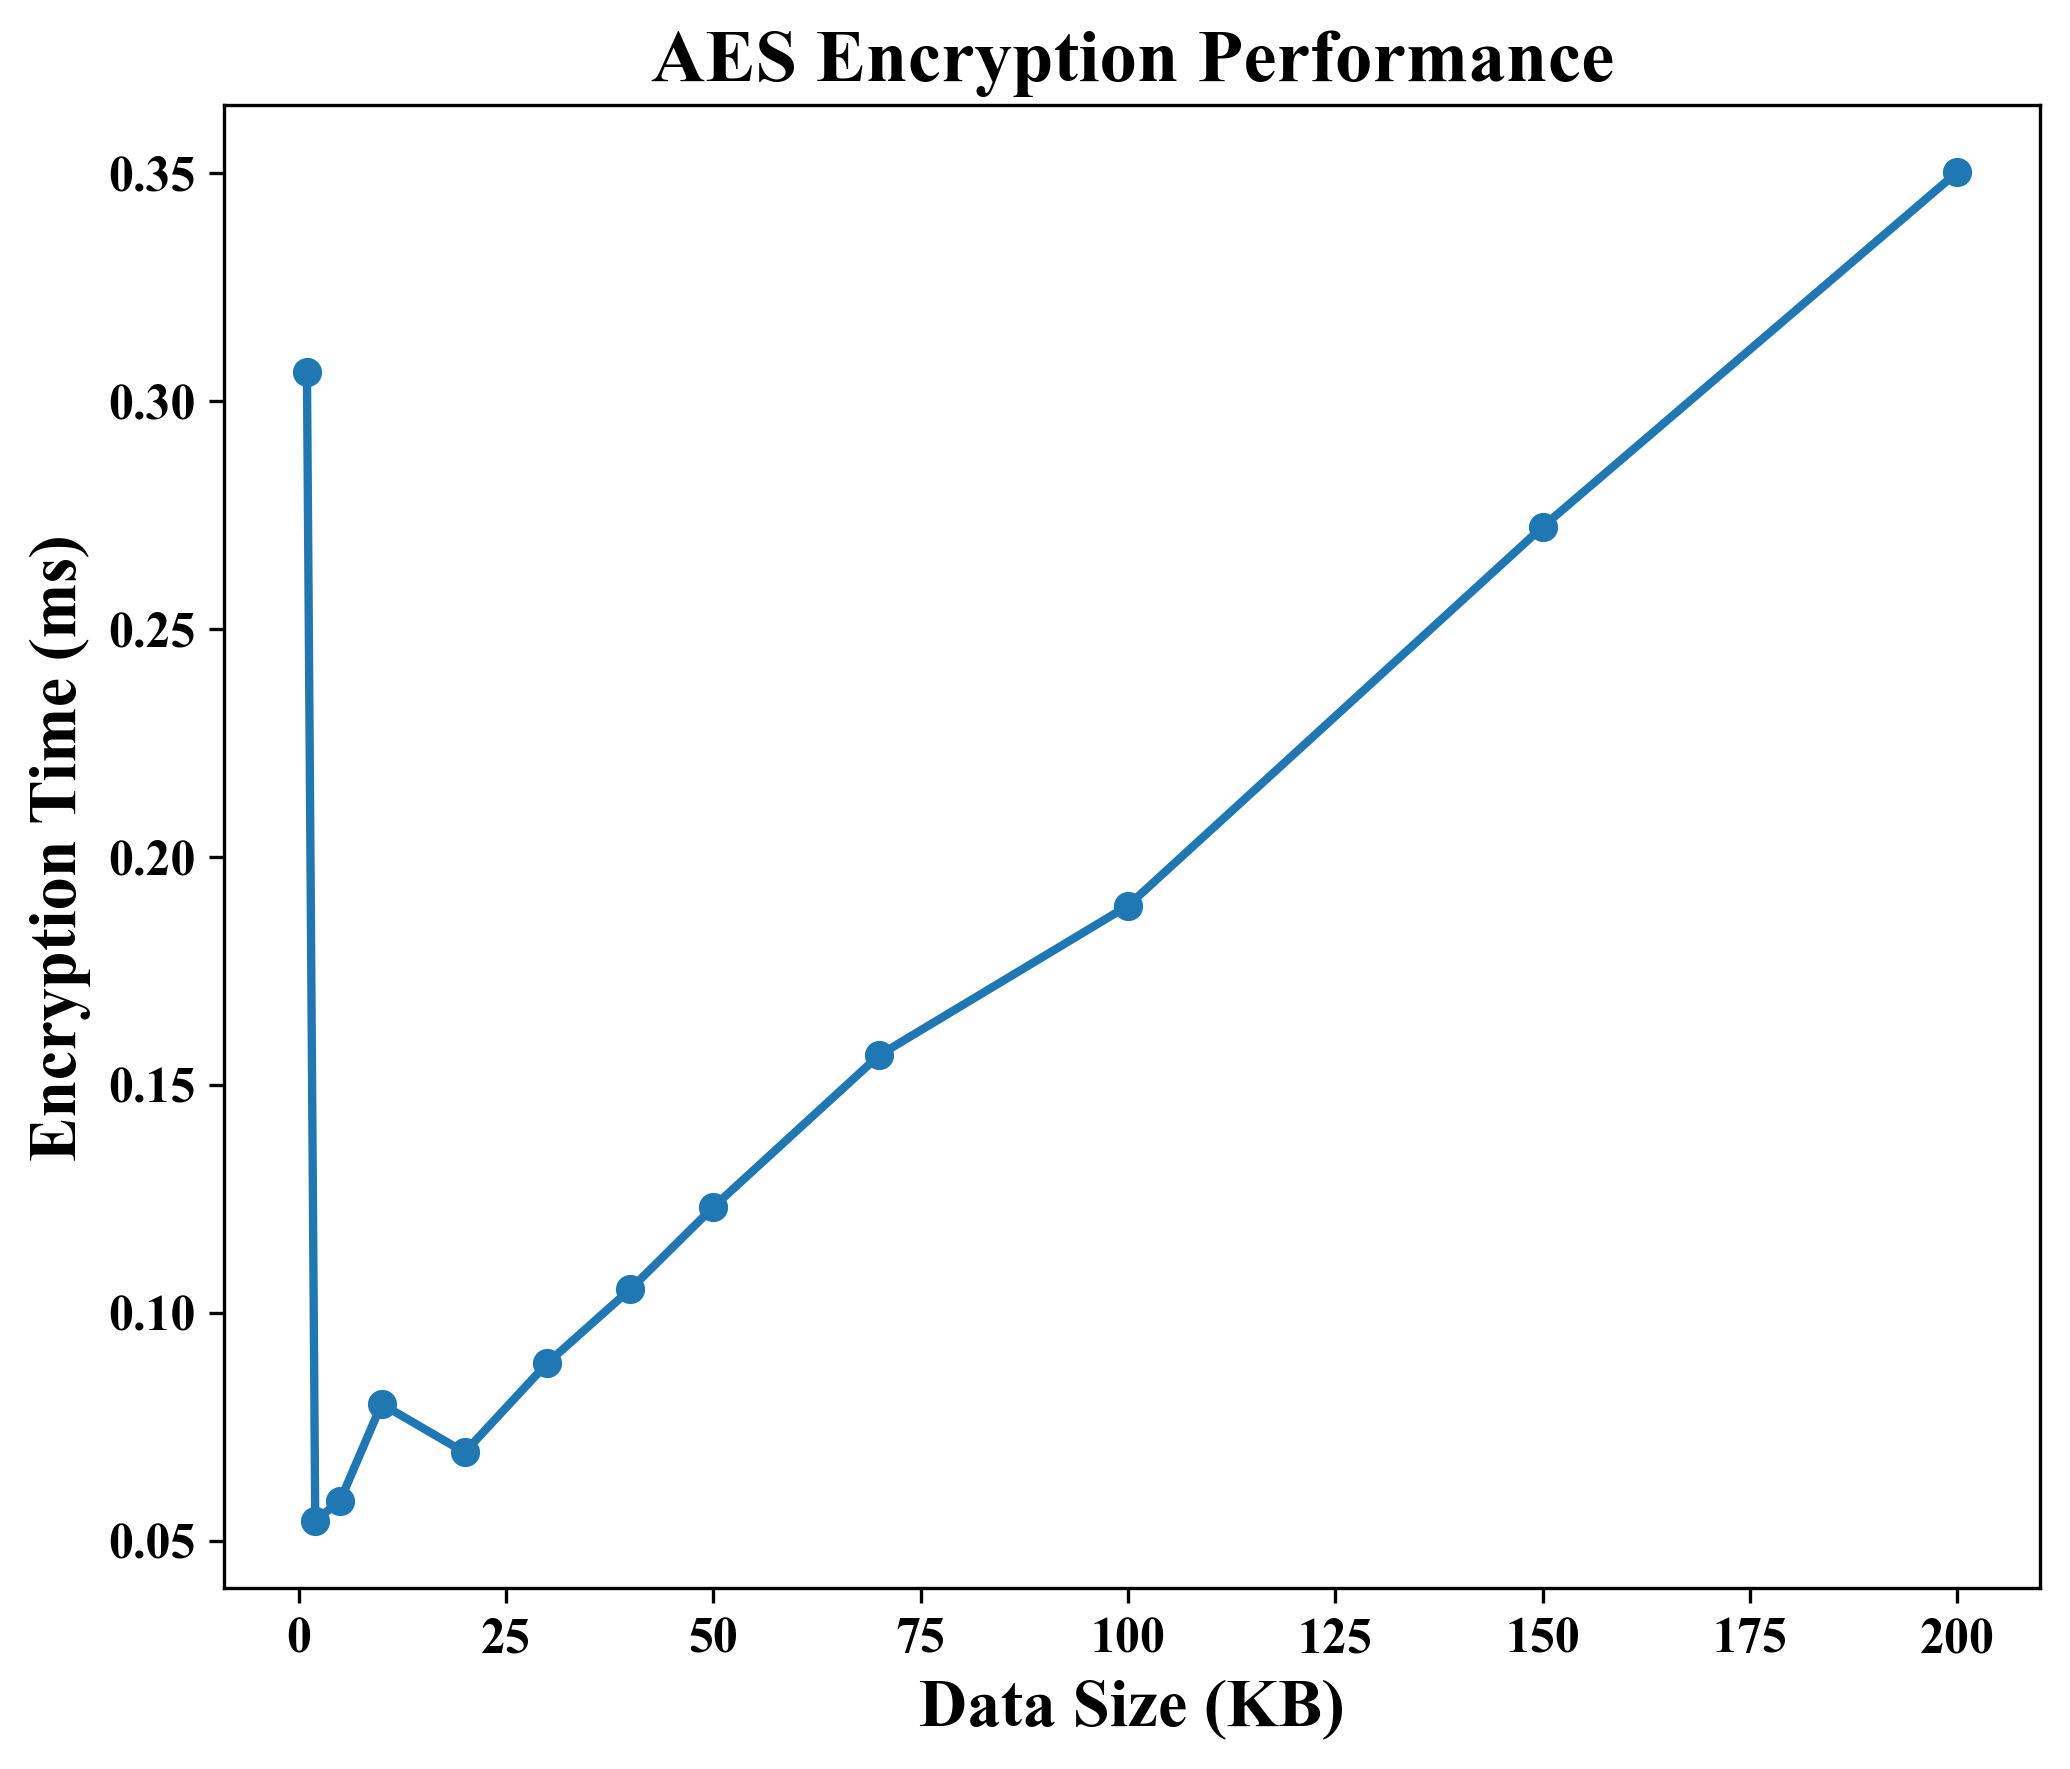

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,6), dpi=300)

plt.plot(
    data_sizes,
    encryption_times,
    marker='o',
    linewidth=2
)

plt.xlabel(
    "Data Size (KB)",
    fontsize=16,
    fontweight='bold',
    fontname='Times New Roman'
)

plt.ylabel(
    "Encryption Time (ms)",
    fontsize=16,
    fontweight='bold',
    fontname='Times New Roman'
)

plt.title(
    "AES Encryption Performance",
    fontsize=18,
    fontweight='bold',
    fontname='Times New Roman'
)

plt.xticks(fontsize=12, fontweight='bold', fontname='Times New Roman')
plt.yticks(fontsize=12, fontweight='bold', fontname='Times New Roman')

plt.grid(False)

plt.tight_layout()

plt.savefig("encryption_time.png", dpi=300)

plt.show()

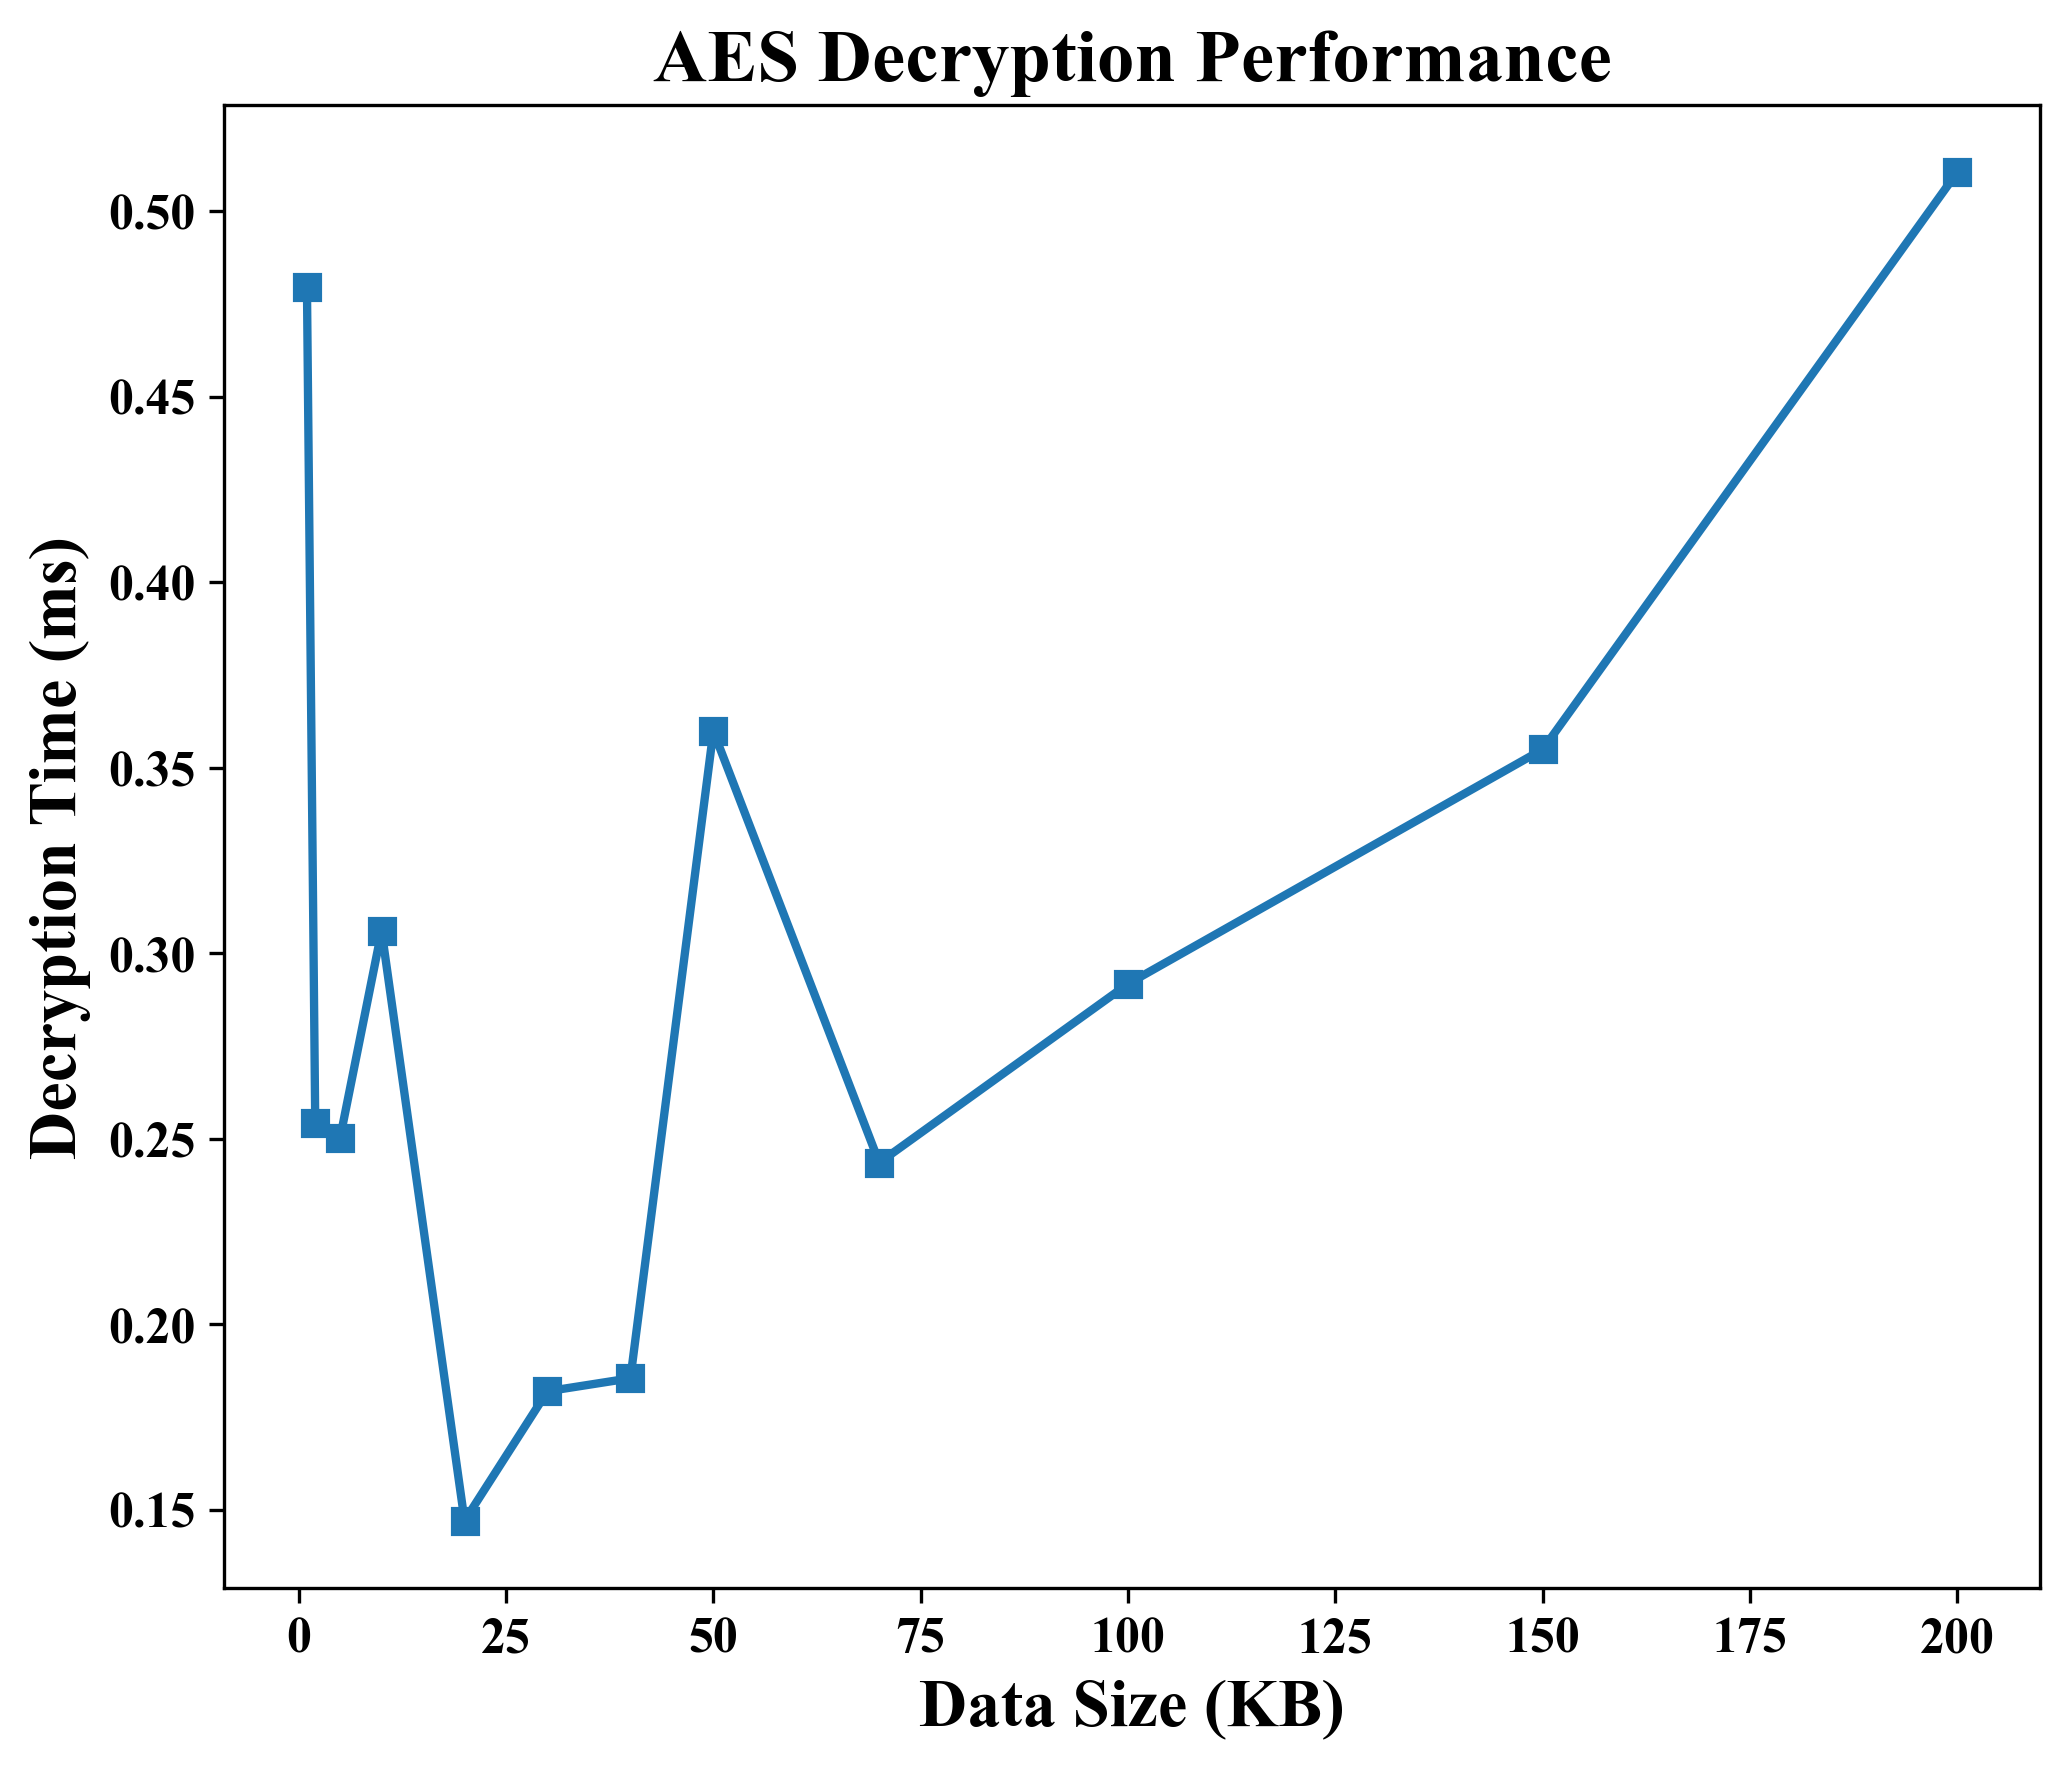

In [53]:
plt.figure(figsize=(7,6), dpi=300)

plt.plot(
    data_sizes,
    decryption_times,
    marker='s',
    linewidth=2
)

plt.xlabel(
    "Data Size (KB)",
    fontsize=16,
    fontweight='bold',
    fontname='Times New Roman'
)

plt.ylabel(
    "Decryption Time (ms)",
    fontsize=16,
    fontweight='bold',
    fontname='Times New Roman'
)

plt.title(
    "AES Decryption Performance",
    fontsize=18,
    fontweight='bold',
    fontname='Times New Roman'
)

plt.xticks(fontsize=12, fontweight='bold', fontname='Times New Roman')
plt.yticks(fontsize=12, fontweight='bold', fontname='Times New Roman')

plt.grid(False)

plt.tight_layout()

plt.savefig("decryption_time.png", dpi=300)

plt.show()